This notebook shows several classes and methods of `ELENA`, making it explicit how to compute the GW spectrum from a Lagrangian input. It showcases the full chain of computation, including:
- defining the model parameters;
- find the critical temperatures;
- compute the action and other relevant quantities over the full range of temperatures;
- compute the thermal parameters entering the GW spectrum computation;
- compute the final GW spectrum.

# Add paths to let Python find the necessary source code

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)

In [2]:
def g_roll(lambda_):
    return ( ((16 * np.pi**2 * lambda_)/3) * (1 - lambda_ * (5 + 2*np.log(2) )/(8 * np.pi**2) ) )**(1/4)

# Construct the scalar potential
The present example uses the minimal dark photon plus dark Higgs model presented in (arXiv:2501.15649 [hep-ph]). Different models can be implemented following the procedure outlined in CosmoTransitions.

In the cell below:
- `lambda_` is the quartic dark-Higgs self-coupling;
- `g` is the dark-photon gauge coupling constant;
- `vev` is the vacuum-expectation-value of the dark-Higgs field at zero temperature;
- `units` is the energy scale in which dimensionful quantities are computed. It must be a string with possible values `"MeV"`, `"GeV"` or `"TeV"`. If not specified, GeV is assumed;
- `description` is a string that can be used to give a human-readable description of the parameter point, useful to recall results later.

This potential assumes the on-shell renormalisation method, thus the quantities defined above are the observable physical ones.

`ELENA` uses `CosmoTransitions` (Comput. Phys. Commun. 183 (2012), 2006-2013 [arXiv:1109.4189 [hep-ph]]) to build the finite-temperature potential. If you use this functionality of please cite it.

In [3]:
import numpy as np
from utils import convert_units
from model import model

units = np.random.choice(list(convert_units.keys())) # This chooses a random energy scale among [MeV, GeV, TeV]

# This selects a pair of couplings for which we expect a first-order phase transition over large intervals of vevs
lambda_ = 1.65e-3
g = 0.54
#vev = np.random.uniform(0, 1e3) # This chooses a random vev between [0, 1e3] in the selected units
vev, units = 500, "MeV"
description = "Fast"

# Alternatively, these are the benchmark points presented in arXiv:2501.15649 [hep-ph]
lambda_, g, vev, units, description  = 6e-3, 0.75002, 500, "MeV", "Slow" # BP1
# lambda_, g, vev, units, description  = 6e-3, 0.74999, 1000, "MeV", "BP2"
# lambda_, g, vev, units, description  = 6e-3, 0.749938, 3, "GeV", "BP3" 
# lambda_, g, vev, units, description  = 1e-2, 0.85412, 1, "GeV", "BP4"

# lambda_, g, vev, units, description =  4.488898148959398e-03, 6.972679726505687e-01, 4.410345365114855e+01, "MeV", "MCMC_MAP"
# lambda_, g, vev, units, description =  3.2068687910412159e-03, 6.4097070950050705e-01, 1.1413675256191728e+02, "MeV", "MCMC_bayes"
# lambda_, g, vev, units, description =  1.5052724071742338e-03, 5.3053740660784832e-01, 4.6720288890003964e+01, "MeV", "MCMC_MLE"

# description = f"vev = {vev} {units}"

# This constructs the finite-temperature potential as an instance of the class model. 
dp = model(vev, lambda_, g, xstep= vev * 1e-3, Tstep=vev * 1e-6)
V = dp.DVtot # This is the scalar potential shifted such that the false vacuum is located at ϕ = 0 for each value of the temperature
dV = dp.gradV # This is the gradient of the scalar potential

print(f"lambda = {lambda_}")
print(f"g = {g}")
print(f"vev = {vev} {units}")

lambda = 0.006
g = 0.75002
vev = 500 MeV


## Plot the potential and gradient at some random temperature and at T = 0

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_78916/3013746582.py:33: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_ylabel(f"$V(\phi, T)$ $[{units}^{4}]$")
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_78916/3013746582.py:37: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_xlabel(f"$\phi$ [{units}]")
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_78916/3013746582.py:38: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_ylabel(f"$dV/d\phi$ $[{units}^{3}]$")


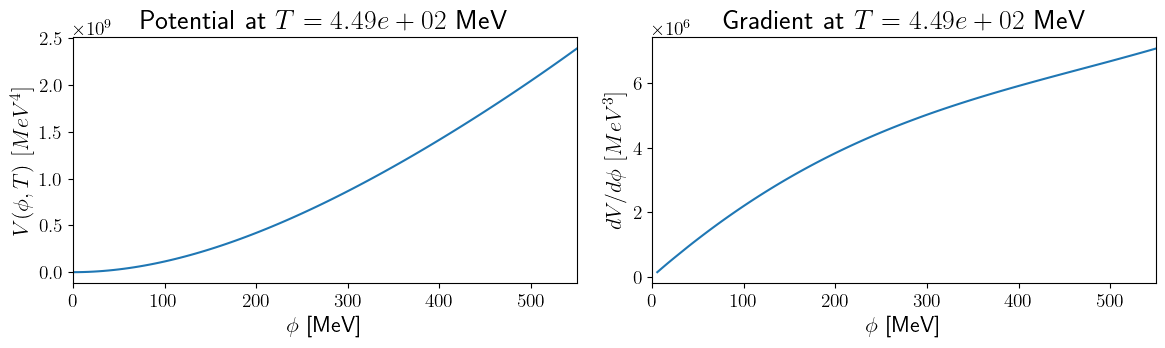

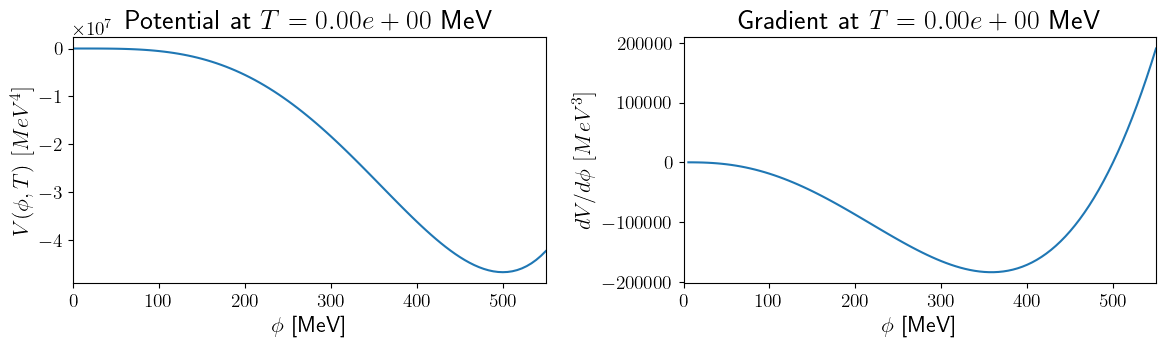

In [4]:
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# Set global font size parameters
plt.rcParams.update({
    'font.size': 18,              # Base font size
    'axes.titlesize': 20,         # Title font size
    'axes.labelsize': 16,         # Label font size
    #'axes.labelweight': 'bold',   # Make axis labels bold
    'xtick.labelsize': 14,        # X-tick label size
    'ytick.labelsize': 14,        # Y-tick label size
    'legend.fontsize': 14,        # Legend font size
    'figure.titlesize': 20,        # Figure title size
    'text.usetex': True,          # Use LaTeX for all text rendering
    'text.latex.preamble': r'\usepackage{amsmath,amssymb,bm}'
})

T = np.random.uniform(0, vev)

phi = np.linspace(0, 1.1 * vev, 100)
phi = phi.reshape(-1,1)

for t in [T, 0]:
    v = V(phi, t)
    dv = dV(phi, t)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(phi, v)
    axes[0].set_title(f"Potential at $T = {t:.2e}$ {units}")
    axes[0].set_xlabel(fr"$\phi$ [{units}]")
    axes[0].set_ylabel(f"$V(\phi, T)$ $[{units}^{4}]$")

    axes[1].plot(phi[1::], dv[1::])
    axes[1].set_title(f"Gradient at $T = {t:.2e}$ {units}")
    axes[1].set_xlabel(f"$\phi$ [{units}]")
    axes[1].set_ylabel(f"$dV/d\phi$ $[{units}^{3}]$")

    for ax in axes:
        ax.set_xlim(phi[0], phi[-1])

    plt.tight_layout()
    plt.show()

# Compute the critical temperatures

The cell below computes the critical temperture `T_max` at which the true and false vacua are degenerate, as well as the temperature `T_min` below which the thermal barrier between the vacua disappears. 

`[T_min, T_max]` is thus the range of temperatures where a first order phase transition can take place.

`maxvev` is the maximum of the location of the true vev for temperatures in `[T_min, T_max]`, a quantity later useful in optimising the computation of the tunneling action.

In [5]:
from temperatures import find_T_min, find_T_max, refine_Tmin

T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(V, dV, precision= 1e-2, Phimax = 2*vev, step_phi = vev * 1e-2, tmax=2.5 * vev)
T_min, vevs_min, false_min_tmin = find_T_min(V, dV, tmax=T_max, precision = 1e-2, Phimax = 2*vev, step_phi = vev * 1e-2, max_min_vals = max_min_vals)

if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None

T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision = 6) if T_min is not None else None

print(f"T_max = {T_max:.6e} {units}")
print(f"T_min = {T_min:.6e} {units}")

T_max = 1.157500e+02 MeV
T_min = 0.000000e+00 MeV


## Plot the potential at the critical temperatures

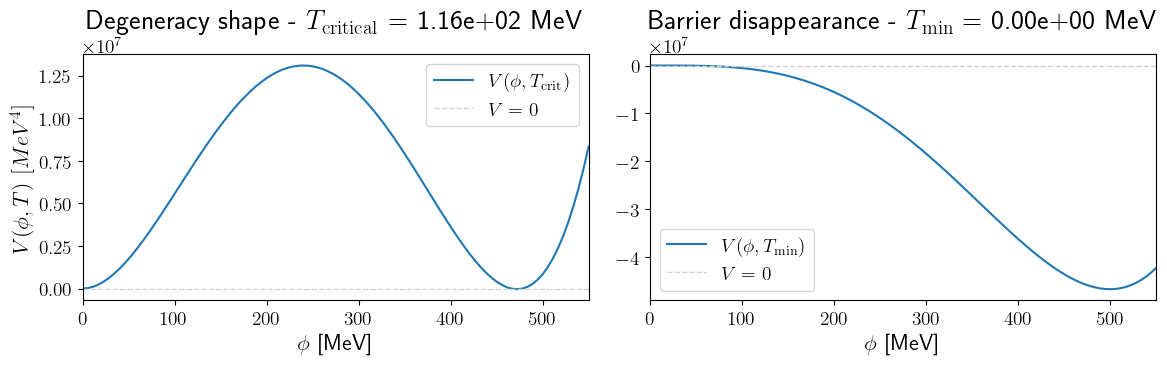

In [6]:
if T_max is not None: v_max = V(phi, T_max)
if T_min is not None: v_min = V(phi, T_min)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if T_max is not None: 
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label = '$V(\phi, T_\\mathrm{{crit}})$')
    axes[0].set_title(f'Degeneracy shape - $T_{{\\mathrm{{critical}}}}$ = {T_max:.2e} {units}')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\phi, T)$ $[{units}^{4}]$")

if T_min is not None: 
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label= '$V(\phi, T_\\mathrm{{min}})$')
    axes[1].set_title(f'Barrier disappearance - $T_{{\\mathrm{{min}}}}$ = {T_min:.2e} {units}')
    axes[1].set_xlim(phi[0], phi[-1])

for ax in axes:
    ax.set_xlabel(f"$\phi$ [{units}]")
    ax.axhline(false_min_tmax[1], color='lightgrey', linestyle='--', linewidth=1, label = "$V = 0$")
    ax.legend()

plt.tight_layout()
plt.show()

# Compute the tunneling action and several other usueful quantities over the relevant temperature range

Define the function that will collect the results of the instances of `espinosa.Vt_vec` for the different temperatures

In [7]:
from espinosa import Vt_vec

true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

def action_over_T(T, c_step_phi = 1e-3, precision = 1e-3):
    instance = Vt_vec(T, V, dV, step_phi = c_step_phi, precision = precision, vev0 = maxvev, ratio_vev_step0=50)
    if instance.barrier:
        true_vev[T] = instance.true_min
        false_vev[T] = instance.phi_original_false_vev
        S3overT[T] = instance.action_over_T
        V_min_value[T] = instance.min_V
        phi0_min[T] = instance.phi0_min
        V_exit[T] = instance.V_exit
        return instance.action_over_T
    else:
        return None

## The cell below computes the tunneling action and other relevant quantities over a large number or temperatures between `T_min` and `T_max`

It stores the results in a collection of dictionaries, where the key is the temeperature and the value the quantity at that specific temperature. The quantities are:
- `S3overT`: the value of the finite-temperature 3-dimensional tunneling action $S_3$ divided by the temperature $T$, i.e. $S_3 / T$;
- `phi0_min`: the value of the field $\phi_{0, min}$ that minimises $S_{E,3}$, c.f. eq. (37) in 1805.03680;
- `V_exit`: the value of the potential at $V(\phi_{0, min})$;
- `true_vev`: location of the true vev;
- `false_vev`: location  of the false vev;
- `V_min_value`: the value of the potential at $V(true\ vev)$.

### This computation only needs to be performed once for a parameter point.

In [8]:
n_points = 500
temperatures = np.linspace(T_min, T_max, n_points)
action_vec = np.vectorize(action_over_T)

start_time = time.time()
action_vec(temperatures)
end_time = time.time()
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

temperatures = np.array([T for T in temperatures if T in S3overT])

Elapsed time: 9.28 seconds


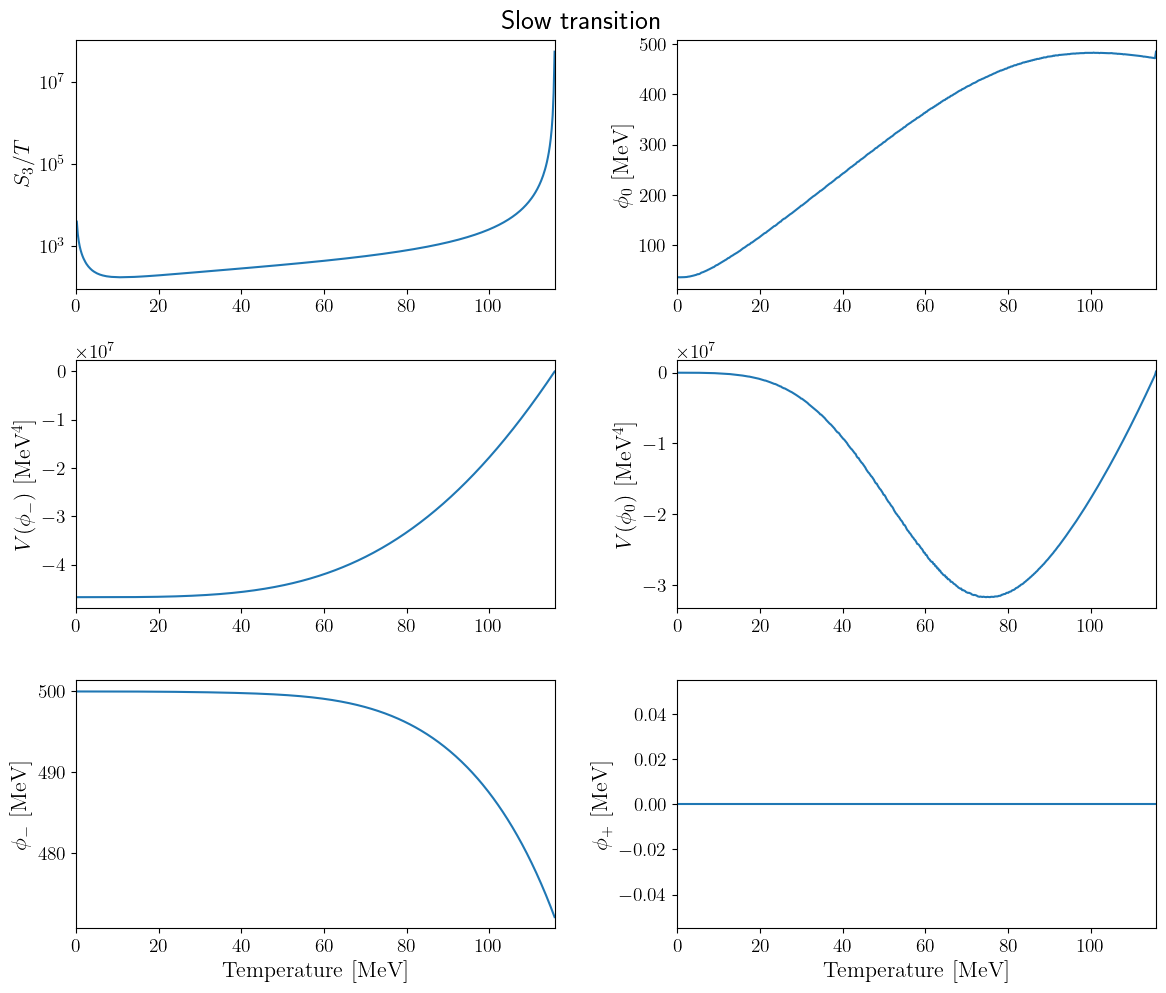

Minimum of the action at T = 1.11e+01 MeV


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(temperatures, [S3overT[T] for T in temperatures])
#axes[0, 0].set_title('$S_3/T$')
#axes[0, 0].set_xlabel(f"T [{units}]")
axes[0, 0].set_ylabel('$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, [phi0_min[T] for T in temperatures])
#axes[0, 1].set_title('$\phi_{0,\mathrm{min}}$')
#axes[0, 1].set_xlabel(f"T [{units}]")
axes[0, 1].set_ylabel(f"$\phi_0\ \mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, [V_min_value[T] for T in temperatures])
#axes[1, 0].set_title('V(true_vev)')
#axes[1, 0].set_xlabel(f"T [{units}]")
axes[1, 0].set_ylabel(f"$V(\phi_-)\ \mathrm{{[{units}^4]}}$") # (f'$V_{{\\mathrm{{min}}}}\ [{units}^4]$')

axes[1, 1].plot(temperatures, [V_exit[T] for T in temperatures])
#axes[1, 1].set_title('$V(\phi_{0,\mathrm{min}})$')
#axes[1, 1].set_xlabel(f"T [{units}]")
axes[1, 1].set_ylabel(f"$V(\phi_0)\ \mathrm{{[{units}^4]}}$") # (f'$V_{{\\mathrm{{exit}}}}\ [{units}^4]$')

axes[2, 0].plot(temperatures, [true_vev[T] for T in temperatures])
#axes[2, 0].set_title('True vev')
axes[2, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\phi_-\ \mathrm{{[{units}]}}$") # (f'$\\phi_{{\\mathrm{{true}}}}$ [{units}]')

axes[2, 1].plot(temperatures, [false_vev[T] for T in temperatures])
#axes[2, 1].set_title('False vev')
axes[2, 1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\phi_+\ \mathrm{{[{units}]}}$") # (f'$\\phi_{{\\mathrm{{false}}}}$ [{units}]')

for ax in axes.flatten():
    ax.set_xlim(temperatures[0], temperatures[-1])

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.00)
plt.savefig(figure_dir + f"action_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Minimum of the action at T = {temperatures[np.argmin([S3overT[T] for T in temperatures])]:.2e} {units}")

# Computation of transition milestones

The cell below uses the above-computed results to compute the milestones of the transition (if any):
- `T_nuc`: the nucleation temperature;
- `T_perc`: the percolation temperature;
- `T_completion`: the completion temperature

If the condition that defines any of the above milestone temperatures is not met, the corresponding temeprature is set to a `nan` value.

The computation is performed two times: the first time spanning over the full range of relevant temperatures between `T_min` and `T_max`, to identify the scale of the transition milestone. The second time over a finer grid of temperature values between `T_completion` and `T_nuc`, to better integrate over the most important range of temperatures defining a first-order phase transition.

The variable `is_physical` is set to `True` if the physical volume of Universe in false vacuum is decreasing at percolation. In the opposite case, the production of GW is questionable (cf. e.g. Section 4.7.2 in [2305.02357] and references therein).

In [10]:
from utils import interpolation_narrow
from temperatures import compute_logP_f, N_bubblesH, R_sepH, compute_logP_f1, compute_logP_f2

is_physical = True

def is_increasing(arr):
    return np.all(arr[:-1] <= arr[1:])

counter = 0
while counter <= 1:
    if counter == 1:
        temperatures = np.linspace(np.nanmax([T_min, 0.95 * T_completion]), np.nanmin([T_max, 1.05 * T_nuc]), n_points, endpoint = True)
        action_vec(temperatures)
    try:
        logP_f, Temps, ratio_V, Gamma, H = compute_logP_f(dp, V_min_value, S3overT, true_vev, false_vev, v_w = 1, units = units, cum_method= 'None')
    except:
        logP_f, Temps, ratio_V, Gamma, H = compute_logP_f(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')
    RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
    nH = N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)
    mask_nH = ~np.isnan(nH)
    T_nuc = interpolation_narrow(np.log(nH[mask_nH]), Temps[mask_nH], 0)
    mask_Pf = ~np.isnan(logP_f)
    T_perc = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.71))
    T_completion = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.01))
    idx_compl = np.max([np.argmin(np.abs(Temps - T_completion)), 1])
    test_completion = np.array([logP_f[idx_compl - 1], logP_f[idx_compl], logP_f[idx_compl + 1]])
    test_completion = test_completion[~np.isnan(test_completion)]
    print(counter, T_completion, test_completion)
    print(is_increasing(test_completion))
    if not is_increasing(test_completion):
        T_completion = np.nan
    if counter == 1:
        d_dT_logP_f = np.gradient(logP_f, Temps)
        log_at_T_perc = interpolation_narrow(Temps, d_dT_logP_f, T_perc)
        ratio_V_at_T_perc = interpolation_narrow(Temps, ratio_V, T_perc)
        log_at_T_completion = interpolation_narrow(Temps, d_dT_logP_f, T_completion)
        ratio_V_at_T_completion = interpolation_narrow(Temps, ratio_V, T_completion)
        if ratio_V_at_T_perc > log_at_T_perc:
            is_physical = False
            print("\n *** The physical volume at percolation is not decreasing. The production of GW is questionable ***")
    counter += 1

milestones = [T_max, T_nuc, T_perc, T_completion, T_min]
milestones = [milestone for milestone in milestones if milestone is not None and not np.isnan(milestone)]
action_vec(milestones)

# This is just for plotting purposes
t_mil_min, t_mil_max = np.nanmin([T_completion, T_perc, T_nuc]), np.nanmax([T_completion, T_perc, T_nuc])
idx_min = max(np.argmin(np.abs(Temps - t_mil_min)), 0)
idx_max = min(np.argmin(np.abs(Temps - t_mil_max)), len(Temps) - 1)
idx_min = idx_min if Temps[idx_min] <= t_mil_min else idx_min - 1
idx_max = idx_max if Temps[idx_max] >= t_mil_max else idx_max + 1
mask = (Temps >= Temps[idx_min]) & (Temps <= Temps[idx_max]) if not np.isnan(t_mil_min) else Temps >= 0

print(f"\nT_nuc = {T_nuc:.6e} {units}")
print(f"T_perc = {T_perc:.6e} {units}")
print(f"T_completion = {T_completion:.6e} {units}\n")

/Users/michele/scratch/ELENA_release/src/temperatures.py:361: RuntimeWarning: invalid value encountered in multiply
  Gamma_list = Temps**4 * (S3_T / (2 * np.pi))**(3/2) * np.exp(-S3_T)
/Users/michele/scratch/ELENA_release/src/temperatures.py:379: RuntimeWarning: overflow encountered in power
  f2 = f_ext[i:] * np.exp(- cum_ratio_V) * cum_f1**3
/Users/michele/scratch/ELENA_release/src/temperatures.py:379: RuntimeWarning: invalid value encountered in multiply
  f2 = f_ext[i:] * np.exp(- cum_ratio_V) * cum_f1**3
/Users/michele/scratch/ELENA_release/src/temperatures.py:992: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_78916/3232870106.py:21: RuntimeWarning: divide by zero encountered in log
  T_nuc = interpolation_narrow(np.log(nH[mask_nH]), Temps[mask_nH], 0)


0 6.434218562561573 [-5.07058354 -4.43995368 -3.86610701]
True
1 6.408287715522598 [-4.67023155 -4.62506404 -4.58020167]
True

T_nuc = 1.390134e+01 MeV
T_perc = 9.619938e+00 MeV
T_completion = 6.408288e+00 MeV



/Users/michele/miniconda3/envs/elena/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in action_over_T (vectorized)
  outputs = ufunc(*args, out=...)


In [29]:
import importlib
import temperatures
importlib.reload(temperatures)
from temperatures import compute_logP_f1, compute_logP_f2,  compute_logP_f3, compute_logP_f5

try:
    logP_f1, Temps1, ratio_V1, Gamma1, H1 = compute_logP_f1(dp, V_min_value, S3overT, true_vev, false_vev, v_w = 1, units = units, cum_method= 'None')
except:
    logP_f1, Temps1, ratio_V1, Gamma1, H1 = compute_logP_f1(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')

try:
    logP_f2, Temps2, ratio_V2, Gamma2, H2 = compute_logP_f2(dp, V_min_value, S3overT, true_vev, false_vev, v_w = 1, units = units, cum_method= 'None')
except:
    logP_f2, Temps2, ratio_V2, Gamma2, H2 = compute_logP_f2(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')


logP_f3, Temps3, ratio_V3, Gamma3, H3, drho3, rhoplusp3, P3, dP3  = compute_logP_f3(dp, V_min_value, S3overT, true_vev, false_vev, v_w = 1, units = units)
                                                              #compute_logP_f3(m, V_min_value, S3overT, true_vev, false_vev, v_w, units = 'GeV', return_all = False)

/Users/michele/scratch/ELENA_release/src/temperatures.py:436: RuntimeWarning: invalid value encountered in multiply
  Gamma_list = Temps**4 * (S3_T / (2 * np.pi))**(3/2) * np.exp(-S3_T)
/Users/michele/scratch/ELENA_release/src/temperatures.py:508: RuntimeWarning: invalid value encountered in multiply
  Gamma_list = Temps**4 * (S3_T / (2 * np.pi))**(3/2) * np.exp(-S3_T)
/Users/michele/scratch/ELENA_release/src/temperatures.py:508: RuntimeWarning: invalid value encountered in multiply
  Gamma_list = Temps**4 * (S3_T / (2 * np.pi))**(3/2) * np.exp(-S3_T)
/Users/michele/scratch/ELENA_release/src/temperatures.py:557: RuntimeWarning: divide by zero encountered in scalar divide
  A_curr = ratio_V[i] / H[i] * np.exp(J / 3.0)
/Users/michele/scratch/ELENA_release/src/temperatures.py:557: RuntimeWarning: divide by zero encountered in scalar divide
  A_curr = ratio_V[i] / H[i] * np.exp(J / 3.0)
/Users/michele/scratch/ELENA_release/src/temperatures.py:676: RuntimeWarning: invalid value encountered 

In [30]:
logP_f5, Temps5, ratio_V5, Gamma5, H5 = compute_logP_f5(dp, V_min_value, S3overT, true_vev, false_vev, v_w = 1, units = units)

/Users/michele/scratch/ELENA_release/src/temperatures.py:894: RuntimeWarning: invalid value encountered in multiply
  for i in range(1, steps):


In [25]:
# Test compute_logP_f5 with debugging
import importlib
import temperatures
importlib.reload(temperatures)
from temperatures import compute_logP_f5

result = compute_logP_f5(
    dp, V_min_value, S3overT, true_vev, false_vev, 
    v_w=1, units=units, return_all=True
)

logP_f5, Temps5, R5, Gamma5, H5, V_ext5, I5, rho_f5, rho_t5, rho_plus_p_f5, rho_plus_p_t5, delta_rho5 = result

print("compute_logP_f5 completed!")
print(f"\nTemperature range: {Temps5.min():.2f} to {Temps5.max():.2f} {units}")
print(f"logP_f range: {np.nanmin(logP_f5):.4e} to {np.nanmax(logP_f5):.4e}")
print(f"V_ext range: {np.nanmin(V_ext5):.4e} to {np.nanmax(V_ext5):.4e}")
print(f"R range: {np.nanmin(R5):.4e} to {np.nanmax(R5):.4e}")
print(f"H range: {np.nanmin(H5):.4e} to {np.nanmax(H5):.4e}")
print(f"\nNaN counts:")
print(f"  logP_f: {np.isnan(logP_f5).sum()}")
print(f"  R: {np.isnan(R5).sum()}")
print(f"  H: {np.isnan(H5).sum()}")
print(f"  rho_plus_p_f: {np.isnan(rho_plus_p_f5).sum()}")
print(f"  rho_plus_p_t: {np.isnan(rho_plus_p_t5).sum()}")

# Check for zero divisions
print(f"\nZero/near-zero counts:")
print(f"  rho_plus_p_f near zero: {(np.abs(rho_plus_p_f5) < 1e-50).sum()}")
print(f"  rho_plus_p_t near zero: {(np.abs(rho_plus_p_t5) < 1e-50).sum()}")
print(f"  H near zero: {(np.abs(H5) < 1e-50).sum()}")

compute_logP_f5 completed!

Temperature range: 0.00 to 115.75 MeV
logP_f range: -4.5116e+01 to 1.1886e-14
V_ext range: -1.1886e-14 to 4.5116e+01
R range: 3.0043e-02 to 1.0964e+01
H range: 2.0636e-23 to 7.9952e-18

NaN counts:
  logP_f: 0
  R: 1
  H: 1
  rho_plus_p_f: 0
  rho_plus_p_t: 0

Zero/near-zero counts:
  rho_plus_p_f near zero: 1
  rho_plus_p_t near zero: 1
  H near zero: 0


In [16]:
# Debug the issue: check where things go wrong
print("Checking thermodynamic quantities at various temperatures:")
print(f"\nTemps5 (first 10 in descending order, from high T):")
# Remember: the output is reversed (low T to high T), so internally it was high T to low T
# Let's look at internal order (high T to low T = last to first in output)
for i in [0, 100, 200, 300, 400, 500, 600, 700]:
    if i < len(Temps5):
        T = Temps5[i]
        print(f"  idx={i}, T={T:.4f}: rho_f={rho_f5[i]:.4e}, rho_t={rho_t5[i]:.4e}, rho+p_f={rho_plus_p_f5[i]:.4e}, rho+p_t={rho_plus_p_t5[i]:.4e}")

# Find where NaN starts
nan_idx = np.where(np.isnan(logP_f5))[0]
if len(nan_idx) > 0:
    first_nan = nan_idx[0]
    print(f"\nFirst NaN at index {first_nan}, T = {Temps5[first_nan]:.4f}")
    if first_nan > 0:
        print(f"Last valid index {first_nan-1}, T = {Temps5[first_nan-1]:.4f}")
        print(f"  logP_f5 = {logP_f5[first_nan-1]:.4e}")
        print(f"  R5 = {R5[first_nan-1]:.4e}")
        print(f"  H5 = {H5[first_nan-1]:.4e}")
        print(f"  rho_f = {rho_f5[first_nan-1]:.4e}")
        print(f"  rho_t = {rho_t5[first_nan-1]:.4e}")
        print(f"  rho+p_f = {rho_plus_p_f5[first_nan-1]:.4e}")
        print(f"  rho+p_t = {rho_plus_p_t5[first_nan-1]:.4e}")

Checking thermodynamic quantities at various temperatures:

Temps5 (first 10 in descending order, from high T):
  idx=0, T=0.0000: rho_f=-2.9873e+04, rho_t=-4.6777e+07, rho+p_f=0.0000e+00, rho+p_t=0.0000e+00
  idx=100, T=7.2486: rho_f=-1.1221e+04, rho_t=-4.6763e+07, rho+p_f=2.0536e+04, rho+p_t=1.4606e+04
  idx=200, T=8.8256: rho_f=1.1125e+04, rho_t=-4.6746e+07, rho+p_f=4.5140e+04, rho+p_t=3.2056e+04
  idx=300, T=10.4025: rho_f=4.9314e+04, rho_t=-4.6717e+07, rho+p_f=8.7182e+04, rho+p_t=6.1983e+04
  idx=400, T=11.9795: rho_f=1.0960e+05, rho_t=-4.6670e+07, rho+p_f=1.5354e+05, rho+p_t=1.0948e+05
  idx=500, T=13.5564: rho_f=1.9949e+05, rho_t=-4.6601e+07, rho+p_f=2.5242e+05, rho+p_t=1.8075e+05
  idx=600, T=22.5005: rho_f=1.7640e+06, rho_t=-4.5346e+07, rho+p_f=1.9677e+06, rho+p_t=1.4732e+06
  idx=700, T=45.6969: rho_f=3.4165e+07, rho_t=-1.7259e+07, rho+p_f=3.6816e+07, rho+p_t=3.0386e+07

First NaN at index 0, T = 0.0000


In [17]:
# Check the structure more carefully
# The internal integration is from high T to low T (descending)
# But the output is reversed to low T to high T (ascending)
# So internally idx=0 is T_max, and the last idx is T_min

# Let's look at the structure of the integration from the internal perspective
# Internal order: Temps sorted descending (high T first)
Temps_internal = Temps5[::-1]  # This reverses back to internal order
rho_f_internal = rho_f5[::-1]
rho_t_internal = rho_t5[::-1]
rho_plus_p_f_internal = rho_plus_p_f5[::-1]
rho_plus_p_t_internal = rho_plus_p_t5[::-1]

print("Internal order (high T to low T):")
for i in [0, 100, 200, 300, 400, 500, 600, 700, len(Temps_internal)-1]:
    if i < len(Temps_internal):
        T = Temps_internal[i]
        print(f"  idx={i}, T={T:.4f}: rho+p_f={rho_plus_p_f_internal[i]:.4e}, rho+p_t={rho_plus_p_t_internal[i]:.4e}")

# Check where rho + p becomes problematic
print("\nWhere rho+p_f becomes small or negative:")
problematic = np.where(rho_plus_p_f_internal < 1e3)[0]
if len(problematic) > 0:
    print(f"  First problematic idx: {problematic[0]}, T={Temps_internal[problematic[0]]:.4f}")
    print(f"  Last problematic idx: {problematic[-1]}, T={Temps_internal[problematic[-1]]:.4f}")
    
# Also check where transition happens
print(f"\nTransition temperatures:")
print(f"  T_nuc = {T_nuc:.4f}")
print(f"  T_perc = {T_perc:.4f}")
print(f"  T_completion = {T_completion:.4f}")
print(f"  T_min = {T_min:.4f}")
print(f"  T_max = {T_max:.4f}")

Internal order (high T to low T):
  idx=0, T=115.7500: rho+p_f=1.8703e+09, rho+p_t=1.7225e+09
  idx=100, T=92.5536: rho+p_f=7.0549e+08, rho+p_t=6.2919e+08
  idx=200, T=69.3572: rho+p_f=2.0971e+08, rho+p_t=1.8060e+08
  idx=300, T=46.1608: rho+p_f=3.8402e+07, rho+p_t=3.1728e+07
  idx=400, T=22.9644: rho+p_f=2.1370e+06, rho+p_t=1.6058e+06
  idx=500, T=13.5903: rho+p_f=2.5498e+05, rho+p_t=1.8260e+05
  idx=600, T=12.0134: rho+p_f=1.5529e+05, rho+p_t=1.1074e+05
  idx=700, T=10.4364: rho+p_f=8.8326e+04, rho+p_t=6.2799e+04
  idx=1002, T=0.0000: rho+p_f=0.0000e+00, rho+p_t=0.0000e+00

Where rho+p_f becomes small or negative:
  First problematic idx: 988, T=3.2475
  Last problematic idx: 1002, T=0.0000

Transition temperatures:
  T_nuc = 13.9013
  T_perc = 9.6199
  T_completion = 6.4083
  T_min = 0.0000
  T_max = 115.7500


In [19]:
# Deeper debug: check where the explosion happens
print("Checking V_ext values at various points:")
mask_valid = ~np.isnan(V_ext5)
valid_temps = Temps5[mask_valid]
valid_Vext = V_ext5[mask_valid]

print(f"\nNumber of valid points: {mask_valid.sum()}")
print(f"Number of NaN points: {(~mask_valid).sum()}")

# Look at the valid range
if len(valid_temps) > 0:
    print(f"\nValid temperature range: {valid_temps.min():.4f} to {valid_temps.max():.4f}")
    print(f"V_ext range in valid region: {valid_Vext.min():.4e} to {valid_Vext.max():.4e}")
    
    # Find where it starts to blow up
    print("\nV_ext values at different temperatures (high T to low T in output = low idx to high idx):")
    for T_check in [T_max, T_nuc, T_perc, T_completion, 5, 3, 1]:
        if T_check is not None:
            idx = np.argmin(np.abs(Temps5 - T_check))
            print(f"  T={Temps5[idx]:.4f}: V_ext={V_ext5[idx]:.4e}, logP_f={logP_f5[idx]:.4e}, H={H5[idx]:.4e}, R={R5[idx]:.4e}")

Checking V_ext values at various points:

Number of valid points: 571
Number of NaN points: 432

Valid temperature range: 12.4882 to 115.7500
V_ext range in valid region: -2.5617e+74 to 6.7268e-261

V_ext values at different temperatures (high T to low T in output = low idx to high idx):
  T=115.7500: V_ext=0.0000e+00, logP_f=0.0000e+00, H=7.9952e-18, R=3.0043e-02
  T=13.9013: V_ext=-1.4162e-04, logP_f=1.4162e-04, H=1.6230e-18, R=1.7247e-01
  T=9.6199: V_ext=nan, logP_f=nan, H=nan, R=nan
  T=6.4083: V_ext=nan, logP_f=nan, H=nan, R=nan
  T=5.1032: V_ext=nan, logP_f=nan, H=nan, R=nan
  T=3.0155: V_ext=nan, logP_f=nan, H=nan, R=nan
  T=0.9279: V_ext=nan, logP_f=nan, H=nan, R=nan


In [20]:
# Find exactly where the NaN starts
valid_mask = ~np.isnan(logP_f5)
# In output order (low T to high T), find the first valid index
first_valid_idx = np.where(valid_mask)[0][0] if valid_mask.any() else None
last_valid_idx = np.where(valid_mask)[0][-1] if valid_mask.any() else None

print(f"In output (low T to high T) order:")
print(f"  First valid idx: {first_valid_idx}, T = {Temps5[first_valid_idx] if first_valid_idx else 'N/A'}")
print(f"  Last valid idx: {last_valid_idx}, T = {Temps5[last_valid_idx] if last_valid_idx else 'N/A'}")

# The internal order is reversed, so let's look at where the NaN starts internally
# Internal: high T to low T
# Output: low T to high T
# So output[0] = internal[-1], output[-1] = internal[0]

print(f"\nLooking around the transition from valid to NaN:")
# Find where NaN starts in output (this is where it ends in internal)
for i in range(max(0, first_valid_idx - 3), min(len(Temps5), first_valid_idx + 5)):
    print(f"  idx={i}, T={Temps5[i]:.4f}: logP_f={logP_f5[i]:.6e}, V_ext={V_ext5[i]:.6e}, R={R5[i]:.4e}, H={H5[i]:.4e}")

# Check what's happening with rho_for_H
print("\nCheck rho + eps_vac * P_f around transition:")
for i in range(max(0, first_valid_idx - 2), min(len(Temps5), first_valid_idx + 5)):
    T = Temps5[i]
    P_f_val = np.exp(logP_f5[i]) if not np.isnan(logP_f5[i]) else np.nan
    print(f"  T={T:.4f}: P_f={P_f_val:.4e}, rho_f={rho_f5[i]:.4e}, rho_t={rho_t5[i]:.4e}")

In output (low T to high T) order:
  First valid idx: 432, T = 12.488159379902887
  Last valid idx: 1002, T = 115.75

Looking around the transition from valid to NaN:
  idx=429, T=12.4373: logP_f=nan, V_ext=nan, R=nan, H=nan
  idx=430, T=12.4542: logP_f=nan, V_ext=nan, R=nan, H=nan
  idx=431, T=12.4712: logP_f=nan, V_ext=nan, R=nan, H=inf
  idx=432, T=12.4882: logP_f=2.561673e+74, V_ext=-2.561673e+74, R=-8.0821e+03, H=2.0688e-18
  idx=433, T=12.5051: logP_f=4.870651e-01, V_ext=-4.870651e-01, R=-1.0151e+04, H=2.0688e-18
  idx=434, T=12.5221: logP_f=6.268889e-04, V_ext=-6.268889e-04, R=5.4053e+01, H=1.6227e-18
  idx=435, T=12.5261: logP_f=1.466133e-03, V_ext=-1.466133e-03, R=-1.9837e+01, H=1.6234e-18
  idx=436, T=12.5390: logP_f=4.443523e-04, V_ext=-4.443523e-04, R=1.1914e+01, H=1.6226e-18

Check rho + eps_vac * P_f around transition:
  T=12.4542: P_f=nan, rho_f=1.3317e+05, rho_t=-4.6652e+07
  T=12.4712: P_f=nan, rho_f=1.3407e+05, rho_t=-4.6652e+07
  T=12.4882: P_f=inf, rho_f=1.3497e+05,

/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_78916/3413259060.py:25: RuntimeWarning: overflow encountered in exp
  P_f_val = np.exp(logP_f5[i]) if not np.isnan(logP_f5[i]) else np.nan


In [26]:
# Compare with all implementations including the new one
print("Comparison with all implementations:")

test_temps = [T_max, T_max * 0.9, T_nuc * 1.1, T_nuc, T_nuc * 0.9, T_perc, T_completion, 5, 3, 1]
print(f"{'T':<12} {'logP_f0':<15} {'logP_f1':<15} {'logP_f2':<15} {'logP_f5':<15}")
print("-" * 75)

for T_test in test_temps:
    if T_test is not None and not np.isnan(T_test) and T_test > 0:
        idx0 = np.argmin(np.abs(Temps - T_test))
        idx1 = np.argmin(np.abs(Temps1 - T_test))
        idx2 = np.argmin(np.abs(Temps2 - T_test))
        idx5 = np.argmin(np.abs(Temps5 - T_test))
        
        print(f"{T_test:<12.4f} {logP_f[idx0]:<15.6e} {logP_f1[idx1]:<15.6e} {logP_f2[idx2]:<15.6e} {logP_f5[idx5]:<15.6e}")

Comparison with all implementations:
T            logP_f0         logP_f1         logP_f2         logP_f5        
---------------------------------------------------------------------------
115.7500     0.000000e+00    0.000000e+00    0.000000e+00    0.000000e+00   
104.1750     -0.000000e+00   -0.000000e+00   0.000000e+00    0.000000e+00   
15.2915      -4.940040e-06   -4.939905e-06   -4.939914e-06   -4.698750e-06  
13.9013      -1.759594e-04   -1.735925e-04   -1.736060e-04   -1.804208e-04  
12.5112      -3.780532e-03   -3.780641e-03   -3.787142e-03   -3.840286e-03  
9.6199       -3.414863e-01   -3.424577e-01   -4.034900e-01   -3.265920e-01  
6.4083       -4.625064e+00   -4.604580e+00   -8.326684e+04   -4.426898e+00  
5.0000       -9.044244e+00   -9.042967e+00   -8.057996e+05   -8.706741e+00  
3.0000       -2.113123e+01   -2.112687e+01   -1.779935e+07   -2.038232e+01  
1.0000       -4.111800e+01   -4.109611e+01   -1.737986e+09   -3.970611e+01  


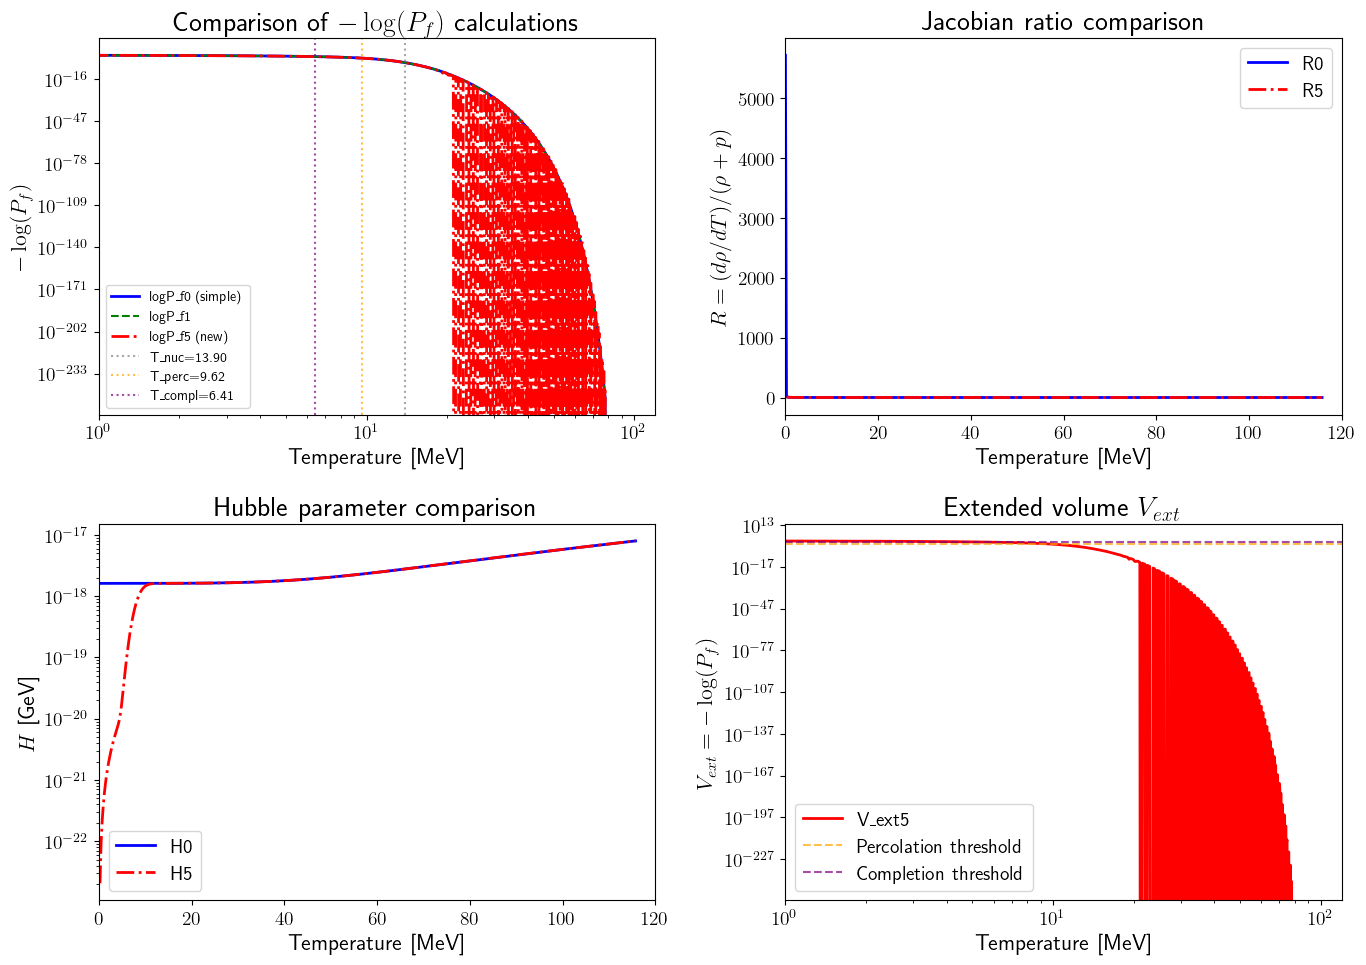


Summary for compute_logP_f5:
  Temperature range: 0.0000 to 115.7500 MeV
  logP_f range: -4.5116e+01 to 1.1886e-14
  No NaN in main computation range (T > 0)


In [31]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: logP_f comparison
ax = axes[0, 0]
ax.plot(Temps, -logP_f, 'b-', linewidth=2, label='logP_f0 (simple)')
ax.plot(Temps1, -logP_f1, 'g--', linewidth=1.5, label='logP_f1')
mask5 = ~np.isnan(logP_f5)
ax.plot(Temps5[mask5], -logP_f5[mask5], 'r-.', linewidth=2, label='logP_f5 (new)')
ax.axvline(T_nuc, color='gray', linestyle=':', alpha=0.7, label=f'T_nuc={T_nuc:.2f}')
ax.axvline(T_perc, color='orange', linestyle=':', alpha=0.7, label=f'T_perc={T_perc:.2f}')
ax.axvline(T_completion, color='purple', linestyle=':', alpha=0.7, label=f'T_compl={T_completion:.2f}')
ax.set_xlabel(f'Temperature [{units}]')
ax.set_ylabel(r'$-\log(P_f)$')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.set_title(r'Comparison of $-\log(P_f)$ calculations')
ax.set_xlim(1, 120)

# Plot 2: Ratio (dρ/dT)/(ρ+p) comparison  
ax = axes[0, 1]
ax.plot(Temps, ratio_V, 'b-', linewidth=2, label='R0')
ax.plot(Temps5[mask5], R5[mask5], 'r-.', linewidth=2, label='R5')
ax.set_xlabel(f'Temperature [{units}]')
ax.set_ylabel(r'$R = (d\rho/dT)/(\rho+p)$')
ax.legend()
ax.set_title('Jacobian ratio comparison')
ax.set_xlim(0, 120)

# Plot 3: Hubble comparison
ax = axes[1, 0]
ax.plot(Temps, H, 'b-', linewidth=2, label='H0')
ax.plot(Temps5[mask5], H5[mask5], 'r-.', linewidth=2, label='H5')
ax.set_xlabel(f'Temperature [{units}]')
ax.set_ylabel(r'$H$ [GeV]')
ax.set_yscale('log')
ax.legend()
ax.set_title('Hubble parameter comparison')
ax.set_xlim(0, 120)

# Plot 4: V_ext
ax = axes[1, 1]
ax.plot(Temps5[mask5], V_ext5[mask5], 'r-', linewidth=2, label='V_ext5')
ax.axhline(-np.log(0.71), color='orange', linestyle='--', alpha=0.7, label='Percolation threshold')
ax.axhline(-np.log(0.01), color='purple', linestyle='--', alpha=0.7, label='Completion threshold')
ax.set_xlabel(f'Temperature [{units}]')
ax.set_ylabel(r'$V_{ext} = -\log(P_f)$')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.set_title(r'Extended volume $V_{ext}$')
ax.set_xlim(1, 120)

plt.tight_layout()
plt.savefig(figure_dir + f"logP_f5_comparison_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSummary for compute_logP_f5:")
print(f"  Temperature range: {Temps5[mask5].min():.4f} to {Temps5[mask5].max():.4f} {units}")
print(f"  logP_f range: {logP_f5[mask5].min():.4e} to {logP_f5[mask5].max():.4e}")
print(f"  No NaN in main computation range (T > 0)")

In [28]:
# Final validation: check P_f at key temperatures
print("P_f values at transition milestones:")
print(f"{'T':<12} {'P_f (0)':<15} {'P_f (1)':<15} {'P_f (5)':<15}")
print("-" * 60)

for T_test, label in [(T_nuc, "T_nuc"), (T_perc, "T_perc"), (T_completion, "T_compl")]:
    if T_test is not None and not np.isnan(T_test) and T_test > 0:
        idx0 = np.argmin(np.abs(Temps - T_test))
        idx1 = np.argmin(np.abs(Temps1 - T_test))
        idx5 = np.argmin(np.abs(Temps5 - T_test))
        
        P_f_0 = np.exp(logP_f[idx0])
        P_f_1 = np.exp(logP_f1[idx1])
        P_f_5 = np.exp(logP_f5[idx5])
        
        print(f"{label:<12} {P_f_0:<15.6e} {P_f_1:<15.6e} {P_f_5:<15.6e}")

print("\nExpected values:")
print(f"  At percolation: P_f ≈ 0.71 (log = -0.34)")
print(f"  At completion:  P_f ≈ 0.01 (log = -4.61)")

P_f values at transition milestones:
T            P_f (0)         P_f (1)         P_f (5)        
------------------------------------------------------------
T_nuc        9.998241e-01    9.998264e-01    9.998196e-01   
T_perc       7.107132e-01    7.100231e-01    7.213780e-01   
T_compl      9.803027e-03    1.000591e-02    1.195151e-02   

Expected values:
  At percolation: P_f ≈ 0.71 (log = -0.34)
  At completion:  P_f ≈ 0.01 (log = -4.61)


In [38]:
# Investigate the oscillation issue in logP_f5 at high temperatures
print("=== Investigating the oscillation issue ===\n")

# Check the size of arrays
print(f"Size of Temps5: {len(Temps5)}")
print(f"Size of Temps (from simpler implementations): {len(Temps)}")

# Check if Temps5 is sorted
diffs = np.diff(Temps5)
is_sorted_ascending = np.all(diffs >= 0)
is_sorted_descending = np.all(diffs <= 0)
print(f"\nTemps5 is sorted ascending: {is_sorted_ascending}")
print(f"Temps5 is sorted descending: {is_sorted_descending}")

# Check for sign changes in diffs (oscillation indicator)
sign_changes = np.sum(np.diff(np.sign(diffs)) != 0)
print(f"Number of sign changes in Temps5 differences: {sign_changes}")

# Look at the first and last few temperature values
print(f"\nFirst 10 values of Temps5: {Temps5[:10]}")
print(f"Last 10 values of Temps5: {Temps5[-10:]}")

# Look at logP_f5 at high temperatures where the issue appears
print(f"\nlogP_f5 at high T (last 20 points, corresponding to high T):")
for i in range(-20, 0):
    print(f"  idx={len(Temps5)+i}, T={Temps5[i]:.6f}, logP_f5={logP_f5[i]:.6e}")

=== Investigating the oscillation issue ===

Size of Temps5: 1003
Size of Temps (from simpler implementations): 1000

Temps5 is sorted ascending: True
Temps5 is sorted descending: False
Number of sign changes in Temps5 differences: 0

First 10 values of Temps5: [0.         0.23196393 0.46392786 0.69589178 0.92785571 1.15981964
 1.39178357 1.62374749 1.85571142 2.08767535]
Last 10 values of Temps5: [113.66232465 113.89428858 114.12625251 114.35821643 114.59018036
 114.82214429 115.05410822 115.28607214 115.51803607 115.75      ]

logP_f5 at high T (last 20 points, corresponding to high T):
  idx=983, T=111.342685, logP_f5=0.000000e+00
  idx=984, T=111.574649, logP_f5=0.000000e+00
  idx=985, T=111.806613, logP_f5=0.000000e+00
  idx=986, T=112.038577, logP_f5=0.000000e+00
  idx=987, T=112.270541, logP_f5=0.000000e+00
  idx=988, T=112.502505, logP_f5=0.000000e+00
  idx=989, T=112.734469, logP_f5=0.000000e+00
  idx=990, T=112.966433, logP_f5=0.000000e+00
  idx=991, T=113.198397, logP_f5=0.0

In [39]:
# Check logP_f5 around the transition region (T ~ 5-20 MeV)
print("=== Checking logP_f5 in transition region ===\n")

# Find indices where T is in the transition region
mask_transition = (Temps5 > 5) & (Temps5 < 25)
T_trans = Temps5[mask_transition]
logP_trans = logP_f5[mask_transition]

print(f"Number of points in transition region (5-25 MeV): {len(T_trans)}")
print(f"\nSample values in transition region:")
for i in range(0, len(T_trans), max(1, len(T_trans)//20)):
    print(f"  T={T_trans[i]:.4f}, logP_f5={logP_trans[i]:.6e}, -logP_f5={-logP_trans[i]:.6e}")

# Check for any NaN or Inf values
print(f"\nNaN in logP_f5: {np.any(np.isnan(logP_f5))}")
print(f"Inf in logP_f5: {np.any(np.isinf(logP_f5))}")

# Check if logP_f5 is monotonic (should be mostly monotonic decreasing with T)
diffs_logP = np.diff(logP_f5)
sign_changes_logP = np.sum(np.diff(np.sign(diffs_logP)) != 0)
print(f"\nSign changes in logP_f5 gradient: {sign_changes_logP}")

# Find where sign changes occur
sign_change_indices = np.where(np.diff(np.sign(diffs_logP)) != 0)[0]
if len(sign_change_indices) > 0:
    print(f"\nFirst 10 sign change locations:")
    for i in sign_change_indices[:10]:
        print(f"  idx={i}, T={Temps5[i]:.6f}, logP_f5={logP_f5[i]:.6e}")

=== Checking logP_f5 in transition region ===

Number of points in transition region (5-25 MeV): 589

Sample values in transition region:
  T=5.1032, logP_f5=-8.706741e+00, -logP_f5=8.706741e+00
  T=6.4856, logP_f5=-4.232714e+00, -logP_f5=4.232714e+00
  T=6.9434, logP_f5=-3.202309e+00, -logP_f5=3.202309e+00
  T=7.4012, logP_f5=-2.362842e+00, -logP_f5=2.362842e+00
  T=7.8590, logP_f5=-1.693373e+00, -logP_f5=1.693373e+00
  T=8.3169, logP_f5=-1.173165e+00, -logP_f5=1.173165e+00
  T=8.7747, logP_f5=-7.814878e-01, -logP_f5=7.814878e-01
  T=9.2325, logP_f5=-4.976790e-01, -logP_f5=4.976790e-01
  T=9.6734, logP_f5=-3.072244e-01, -logP_f5=3.072244e-01
  T=10.1312, logP_f5=-1.763304e-01, -logP_f5=1.763304e-01
  T=10.5890, logP_f5=-9.558341e-02, -logP_f5=9.558341e-02
  T=11.0469, logP_f5=-4.888026e-02, -logP_f5=4.888026e-02
  T=11.5047, logP_f5=-2.352692e-02, -logP_f5=2.352692e-02
  T=11.9625, logP_f5=-1.064550e-02, -logP_f5=1.064550e-02
  T=12.4203, logP_f5=-4.534928e-03, -logP_f5=4.534928e-03
 

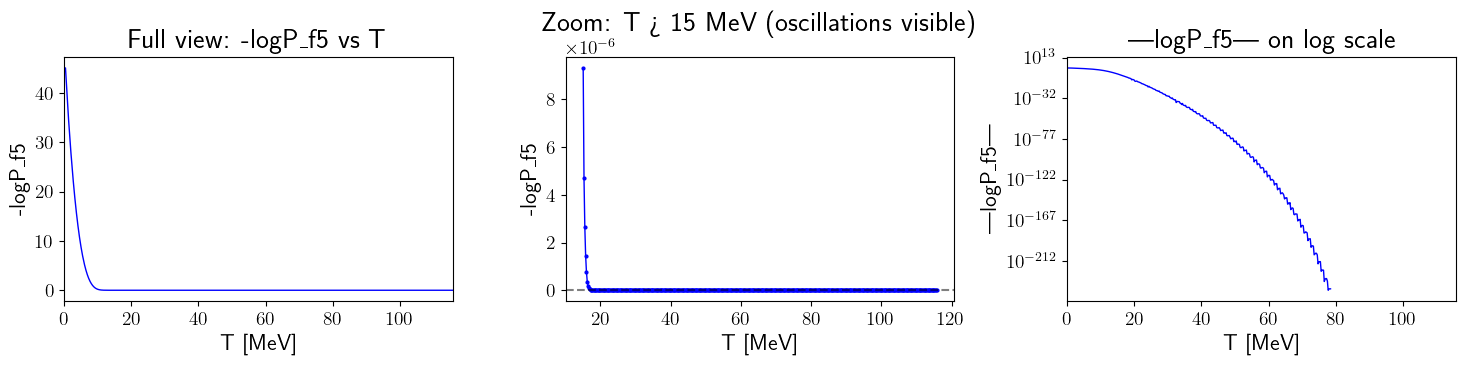


=== Diagnosis ===
The oscillations at high T are due to numerical noise near zero.
At T > 20 MeV, |logP_f5| ~ 10^{-12} to 10^{-17}, which oscillates around 0
This causes the 'filled region' appearance when plotting -logP_f5.


In [40]:
# Visualize the oscillation issue at high temperatures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Full view of -logP_f5 (as plotted in the issue)
ax1 = axes[0]
ax1.plot(Temps5, -logP_f5, 'b-', linewidth=1)
ax1.set_xlabel('T [MeV]')
ax1.set_ylabel('-logP_f5')
ax1.set_title('Full view: -logP_f5 vs T')
ax1.set_xlim(0, T_max)

# Panel 2: Zoom on high-T region where oscillations occur
ax2 = axes[1]
high_T_mask = Temps5 > 15
ax2.plot(Temps5[high_T_mask], -logP_f5[high_T_mask], 'b-', linewidth=1, marker='o', markersize=2)
ax2.set_xlabel('T [MeV]')
ax2.set_ylabel('-logP_f5')
ax2.set_title('Zoom: T > 15 MeV (oscillations visible)')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)

# Panel 3: Log-scale to see the oscillations better
ax3 = axes[2]
# Use absolute value with log scale
abs_logP = np.abs(logP_f5)
valid_mask = abs_logP > 0
ax3.semilogy(Temps5[valid_mask], abs_logP[valid_mask], 'b-', linewidth=1)
ax3.set_xlabel('T [MeV]')
ax3.set_ylabel('|logP_f5|')
ax3.set_title('|logP_f5| on log scale')
ax3.set_xlim(0, T_max)

plt.tight_layout()
plt.show()

print("\n=== Diagnosis ===")
print("The oscillations at high T are due to numerical noise near zero.")
print(f"At T > 20 MeV, |logP_f5| ~ 10^{{-12}} to 10^{{-17}}, which oscillates around 0")
print("This causes the 'filled region' appearance when plotting -logP_f5.")

In [44]:
# Summary of the oscillation issue
print("=== ROOT CAUSE ANALYSIS ===\n")

print("The oscillation issue at high temperatures is caused by:")
print("1. At T > T_nuc (~14 MeV), the nucleation rate Γ ~ exp(-S₃/T) is essentially zero")
print("2. The true logP_f value should be exactly 0 (no bubbles formed yet)")
print("3. The ODE solver accumulates numerical errors as it integrates")
print("4. These errors oscillate around zero at the level of 10⁻¹² to 10⁻¹⁷")
print("\n5. When plotting -logP_f5, these tiny oscillations get magnified")
print("   and appear as a 'filled region' because the values go both")
print("   slightly positive and slightly negative around zero.")

# Show the range of oscillation
high_T_mask = Temps5 > 20
oscillation_range = logP_f5[high_T_mask]
print(f"\nAt T > 20 MeV:")
print(f"  Min logP_f5: {oscillation_range.min():.6e}")
print(f"  Max logP_f5: {oscillation_range.max():.6e}")
print(f"  Range: {oscillation_range.max() - oscillation_range.min():.6e}")

# This is purely numerical noise - the physical value should be exactly 0
print(f"\nFor reference, at T = T_perc = 9.6 MeV, logP_f5 = {logP_f5[np.argmin(np.abs(Temps5 - 9.6))]:.6e}")
print("So the oscillation amplitude at high T is ~10¹⁵ times smaller than the actual signal.")

=== ROOT CAUSE ANALYSIS ===

The oscillation issue at high temperatures is caused by:
1. At T > T_nuc (~14 MeV), the nucleation rate Γ ~ exp(-S₃/T) is essentially zero
2. The true logP_f value should be exactly 0 (no bubbles formed yet)
3. The ODE solver accumulates numerical errors as it integrates
4. These errors oscillate around zero at the level of 10⁻¹² to 10⁻¹⁷

5. When plotting -logP_f5, these tiny oscillations get magnified
   and appear as a 'filled region' because the values go both
   slightly positive and slightly negative around zero.

At T > 20 MeV:
  Min logP_f5: -1.569666e-13
  Max logP_f5: 1.188624e-14
  Range: 1.688529e-13

For reference, at T = T_perc = 9.6 MeV, logP_f5 = -3.319673e-01
So the oscillation amplitude at high T is ~10¹⁵ times smaller than the actual signal.


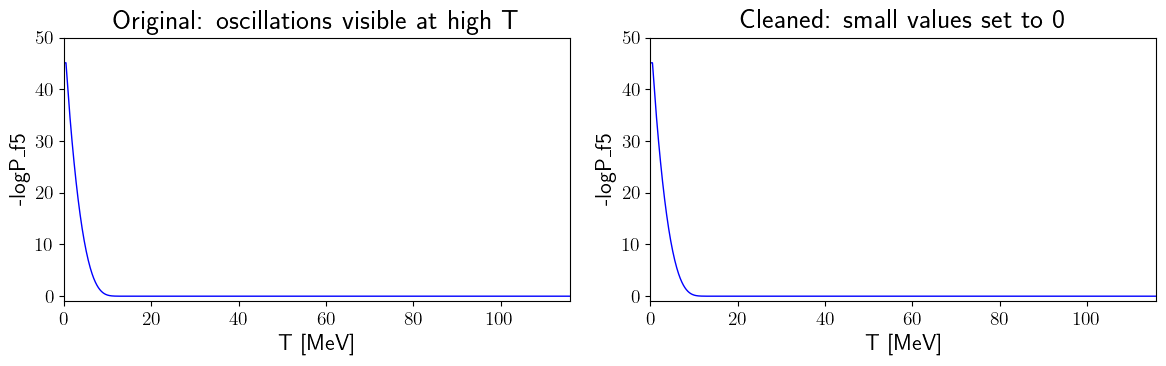


NOTE: The oscillations are purely numerical noise at ~10⁻¹³ level.
They have no physical significance and can be safely ignored or clipped to 0.


In [45]:
# Solution: when plotting, set small values to zero or use a threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Original plot showing the issue
ax1 = axes[0]
ax1.plot(Temps5, -logP_f5, 'b-', linewidth=1)
ax1.set_xlabel('T [MeV]')
ax1.set_ylabel('-logP_f5')
ax1.set_title('Original: oscillations visible at high T')
ax1.set_xlim(0, T_max)
ax1.set_ylim(-1, 50)

# Panel 2: Clean plot by clipping small values
ax2 = axes[1]
# Set values with |logP_f5| < 1e-10 to exactly 0
logP_f5_clean = np.where(np.abs(logP_f5) < 1e-10, 0, logP_f5)
ax2.plot(Temps5, -logP_f5_clean, 'b-', linewidth=1)
ax2.set_xlabel('T [MeV]')
ax2.set_ylabel('-logP_f5')
ax2.set_title('Cleaned: small values set to 0')
ax2.set_xlim(0, T_max)
ax2.set_ylim(-1, 50)

plt.tight_layout()
plt.show()

print("\nNOTE: The oscillations are purely numerical noise at ~10⁻¹³ level.")
print("They have no physical significance and can be safely ignored or clipped to 0.")

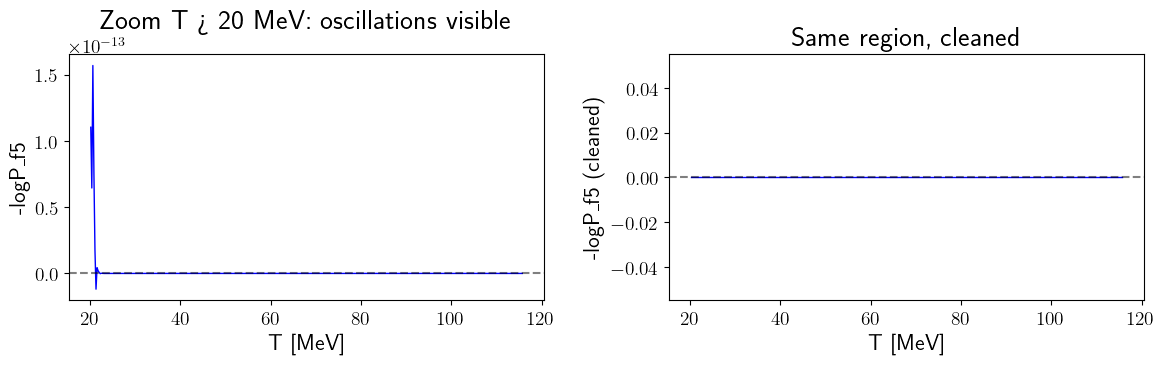

Left panel: the auto-scaled y-axis shows oscillations around zero at 10⁻¹³ level
Right panel: after clipping |logP_f5| < 10⁻¹⁰ to zero, the line is clean


In [46]:
# Zoom in on high-T region to see the oscillations more clearly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Zoom on high T with the issue visible
ax1 = axes[0]
mask = Temps5 > 20
ax1.plot(Temps5[mask], -logP_f5[mask], 'b-', linewidth=1)
ax1.set_xlabel('T [MeV]')
ax1.set_ylabel('-logP_f5')
ax1.set_title('Zoom T > 20 MeV: oscillations visible')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# Don't set y limits - let it auto-scale to show the oscillations

# Panel 2: Same region but cleaned
ax2 = axes[1]
logP_f5_clean = np.where(np.abs(logP_f5) < 1e-10, 0, logP_f5)
ax2.plot(Temps5[mask], -logP_f5_clean[mask], 'b-', linewidth=1)
ax2.set_xlabel('T [MeV]')
ax2.set_ylabel('-logP_f5 (cleaned)')
ax2.set_title('Same region, cleaned')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Left panel: the auto-scaled y-axis shows oscillations around zero at 10⁻¹³ level")
print("Right panel: after clipping |logP_f5| < 10⁻¹⁰ to zero, the line is clean")

In [172]:
# Compare logP_f5 with other implementations
print("Comparison at different temperatures:")
print(f"{'T':<10} {'logP_f':>15} {'logP_f1':>15} {'logP_f2':>15} {'logP_f5':>15}")
print("-" * 70)

for T_test in [T_max * 0.99, T_nuc, T_perc, T_completion]:
    if T_test is not None and not np.isnan(T_test):
        idx = np.argmin(np.abs(Temps - T_test))
        idx1 = np.argmin(np.abs(Temps1 - T_test))
        idx2 = np.argmin(np.abs(Temps2 - T_test))
        idx5 = np.argmin(np.abs(Temps5 - T_test))
        print(f"{T_test:<10.4f} {logP_f[idx]:>15.6e} {logP_f1[idx1]:>15.6e} {logP_f2[idx2]:>15.6e} {logP_f5[idx5]:>15.6e}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# logP_f comparison
ax = axes[0, 0]
mask = ~np.isnan(logP_f)
ax.plot(Temps[mask], -logP_f[mask], label='logP_f0', linewidth=2)
mask1 = ~np.isnan(logP_f1)
ax.plot(Temps1[mask1], -logP_f1[mask1], '--', label='logP_f1')
mask2 = ~np.isnan(logP_f2)
ax.plot(Temps2[mask2], -logP_f2[mask2], ':', label='logP_f2')
mask5 = ~np.isnan(logP_f5)
ax.plot(Temps5[mask5], -logP_f5[mask5], '-.', label='logP_f5', linewidth=2)
ax.set_xlabel('T [MeV]')
ax.set_ylabel('-log(P_f)')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.set_title('-log(P_f) comparison')

# R comparison
ax = axes[0, 1]
ax.plot(Temps, ratio_V, label='ratio_V0', linewidth=2)
ax.plot(Temps1, ratio_V1, '--', label='ratio_V1')
ax.plot(Temps2, ratio_V2, ':', label='ratio_V2')
ax.plot(Temps5[mask5], R5[mask5], '-.', label='R5', linewidth=2)
ax.set_xlabel('T [MeV]')
ax.set_ylabel('R = (dρ/dT)/(ρ+p)')
ax.set_xscale('log')
ax.legend()
ax.set_title('Ratio comparison')

# H comparison
ax = axes[1, 0]
ax.plot(Temps, H, label='H0', linewidth=2)
ax.plot(Temps1, H1, '--', label='H1')
ax.plot(Temps2, H2, ':', label='H2')
ax.plot(Temps5[mask5], H5[mask5], '-.', label='H5', linewidth=2)
ax.set_xlabel('T [MeV]')
ax.set_ylabel('H [GeV]')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.set_title('Hubble comparison')

# V_ext
ax = axes[1, 1]
ax.plot(Temps5[mask5], V_ext5[mask5], label='V_ext5')
ax.set_xlabel('T [MeV]')
ax.set_ylabel('V_ext')
ax.set_xscale('log')
ax.legend()
ax.set_title('V_ext from compute_logP_f5')

plt.tight_layout()
plt.show()

Comparison at different temperatures:
T                   logP_f         logP_f1         logP_f2         logP_f5
----------------------------------------------------------------------
114.5925     -0.000000e+00   -0.000000e+00    0.000000e+00    0.000000e+00
13.9009      -1.735350e-04   -1.737722e-04   -1.737859e-04   -2.685696e-10
9.6199       -3.424685e-01   -3.424614e-01   -4.037259e-01   -5.758305e-08
6.4070       -4.601790e+00   -4.604588e+00   -8.476866e+04   -6.750718e-08


RuntimeError: latex was not able to process the following string:
b'R = (d\\u03c1/dT)/(\\u03c1+p)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpbfs78im3 96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex
LaTeX2e <2020-02-02> patch level 5
L3 programming layer <2020-03-06>
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/article.cls
Document Class: article 2019/12/20 v1.4l Standard LaTeX document class
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2020/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2020/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/202

Error in callback <function _draw_all_if_interactive at 0x1671be840> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'R = (d\\u03c1/dT)/(\\u03c1+p)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp8dz4zhar 96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex
LaTeX2e <2020-02-02> patch level 5
L3 programming layer <2020-03-06>
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/article.cls
Document Class: article 2019/12/20 v1.4l Standard LaTeX document class
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2020/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2020/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/202

RuntimeError: latex was not able to process the following string:
b'R = (d\\u03c1/dT)/(\\u03c1+p)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpzbaexfcx 96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./96bd81443fe45e6e0763c78ec0db4c9e7d482082979aec74bc3a333683b1e427.tex
LaTeX2e <2020-02-02> patch level 5
L3 programming layer <2020-03-06>
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/article.cls
Document Class: article 2019/12/20 v1.4l Standard LaTeX document class
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2020/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2020/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2020/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/202

<Figure size 1200x1000 with 4 Axes>

In [144]:
# Check H values at a few points
print("H values at T ≈ 10 MeV (during transition):")
idx1 = np.argmin(np.abs(Temps1 - 10))
idx2 = np.argmin(np.abs(Temps2 - 10))
idx3 = np.argmin(np.abs(Temps3 - 10))
print(f"H1[{idx1}] at T={Temps1[idx1]:.2f}: {H1[idx1]:.4e}")
print(f"H2[{idx2}] at T={Temps2[idx2]:.2f}: {H2[idx2]:.4e}")
print(f"H3[{idx3}] at T={Temps3[idx3]:.2f}: {H3[idx3]:.4e}")

print("\nH values at T ≈ 1 MeV (after transition):")
idx1 = np.argmin(np.abs(Temps1 - 1))
idx2 = np.argmin(np.abs(Temps2 - 1))
idx3 = np.argmin(np.abs(Temps3 - 1))
print(f"H1[{idx1}] at T={Temps1[idx1]:.2f}: {H1[idx1]:.4e}")
print(f"H2[{idx2}] at T={Temps2[idx2]:.2f}: {H2[idx2]:.4e}")
print(f"H3[{idx3}] at T={Temps3[idx3]:.2f}: {H3[idx3]:.4e}")

# Check P_f values too
print("\nP_f values at T ≈ 10 MeV:")
idx2 = np.argmin(np.abs(Temps2 - 10))
idx3 = np.argmin(np.abs(Temps3 - 10))
print(f"P_f2 at T={Temps2[idx2]:.2f}: {np.exp(logP_f2[idx2]):.4e}")
print(f"P_f3 at T={Temps3[idx3]:.2f}: {np.exp(logP_f3[idx3]):.4e}")

H values at T ≈ 10 MeV (during transition):
H1[507] at T=10.00: 1.6214e-18
H2[507] at T=10.00: 1.4362e-18
H3[507] at T=10.00: 1.4362e-18

H values at T ≈ 1 MeV (after transition):
H1[4] at T=0.93: 1.6209e-18
H2[4] at T=0.93: 3.7960e-22
H3[4] at T=0.93: 3.7960e-22

P_f values at T ≈ 10 MeV:
P_f2 at T=10.00: 7.8441e-01
P_f3 at T=10.00: 7.8445e-01


In [168]:
P3[0]

np.float64(0.0)

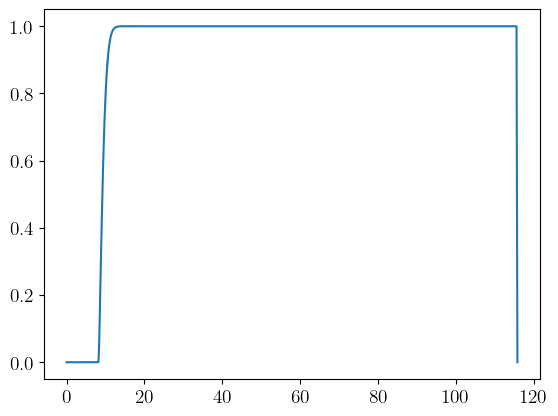

In [159]:
plt.plot(Temps3, P3)
#plt.plot(Temps, np.exp(logP_f))
# plt.plot(Temps3, dP3)
# plt.yscale('log')
# plt.xscale('log')

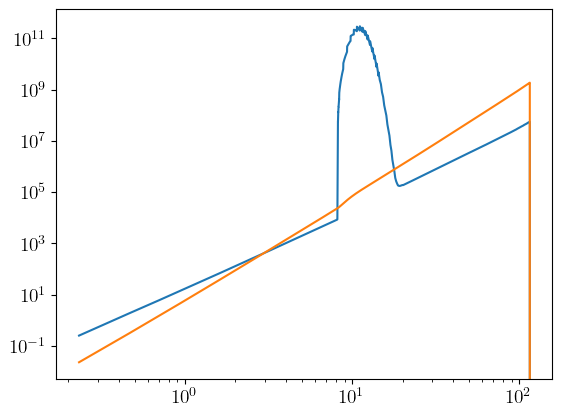

In [153]:
plt.plot(Temps3, drho3)
plt.plot(Temps3, rhoplusp3)
plt.yscale('log')
plt.xscale('log')

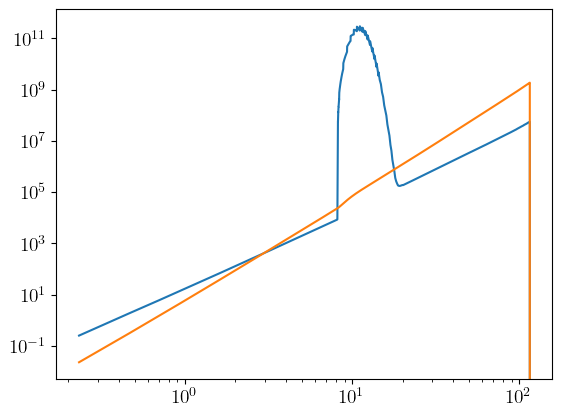

In [154]:
plt.plot(Temps3, drho3)
plt.plot(Temps3, rhoplusp3)
plt.yscale('log')
plt.xscale('log')

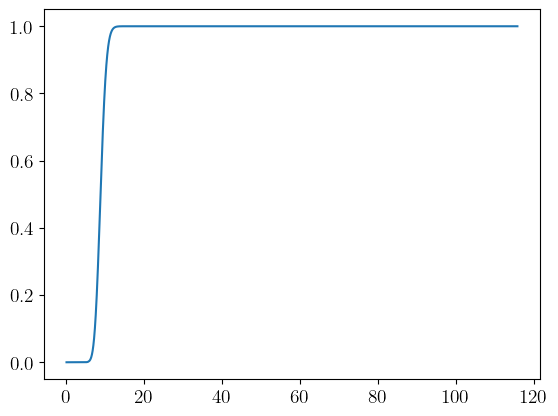

In [105]:
plt.plot(Temps, np.exp(logP_f))

In [37]:
logP_f5

array([-45.11623001, -45.11623001, -45.11623001, ...,   0.        ,
         0.        ,   0.        ], shape=(1003,))

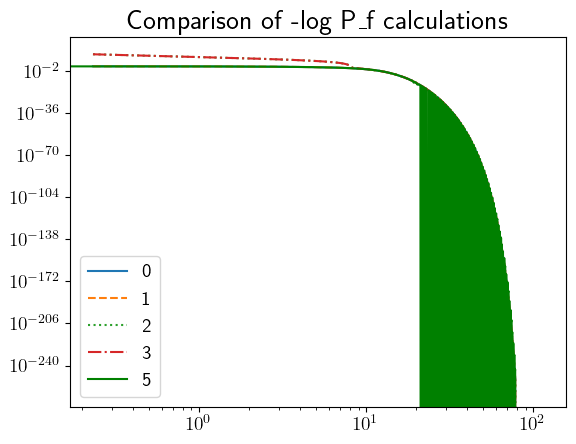

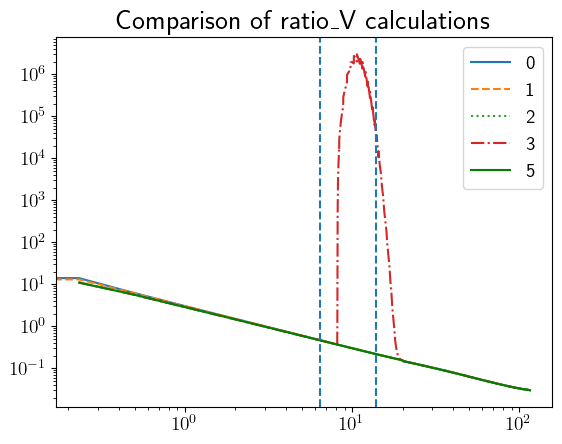

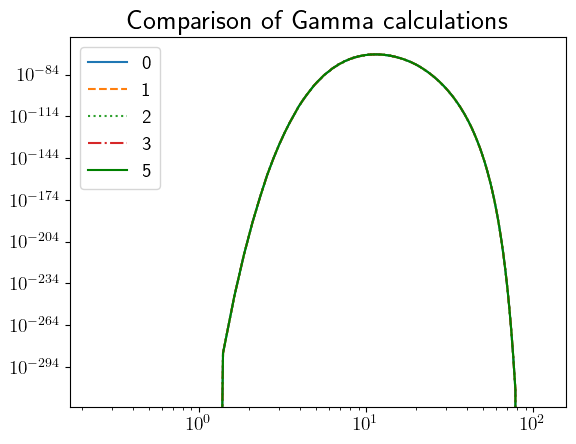

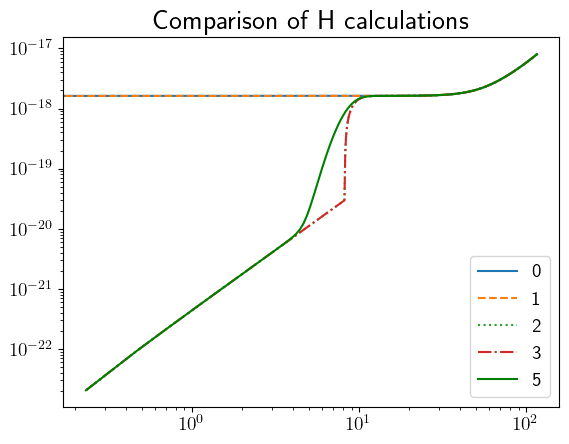

In [36]:
plt.plot(Temps, -logP_f, label = '0')
plt.plot(Temps1, -logP_f1, linestyle = "--", label = '1')
plt.plot(Temps2, -logP_f2, linestyle = ":", label = '2')
plt.plot(Temps3, -logP_f3, linestyle = "-.", label = '3')
plt.plot(Temps5, -logP_f5, linestyle = "-", color='green', label = '5')
plt.yscale('log')
plt.xscale('log')
plt.title('Comparison of -log P_f calculations')
plt.legend()
plt.show()

plt.plot(Temps, ratio_V, label = '0')
plt.plot(Temps1, ratio_V1, linestyle = "--", label = '1')
plt.plot(Temps2, ratio_V2, linestyle = ":", label = '2')
plt.plot(Temps3, ratio_V3, linestyle = "-.", label = '3')
plt.plot(Temps5, ratio_V5, linestyle = "-",color='green', label = '5')
plt.axvline(T_nuc, linestyle = '--')
plt.axvline(T_completion, linestyle = '--')
plt.yscale('log')
plt.xscale('log')
plt.title('Comparison of ratio_V calculations')
plt.legend()
plt.show()

plt.plot(Temps, Gamma, label = '0')
plt.plot(Temps1, Gamma1, linestyle = "--", label = '1')
plt.plot(Temps2, Gamma2, linestyle = ":", label = '2')
plt.plot(Temps3, Gamma3, linestyle = "-.", label = '3')
plt.plot(Temps5, Gamma5, linestyle = "-", color='green', label = '5')
plt.yscale('log')
plt.xscale('log')
plt.title('Comparison of Gamma calculations')
plt.legend()
plt.show()

plt.plot(Temps, H, label = '0')
plt.plot(Temps1, H1, linestyle = "--", label = '1')
plt.plot(Temps2, H2, linestyle = ":", label = '2')
plt.plot(Temps2, H3, linestyle = "-.", label = '3')
plt.plot(Temps5, H5, linestyle = "-", color='green', label = '5')
plt.yscale('log')
plt.xscale('log')
plt.title('Comparison of H calculations')
plt.legend()
plt.show()

In [228]:
# import importlib

# import espinosa
# importlib.reload(espinosa)

# from espinosa import Vt_vec

# #action_over_T(5.198799361554253)
# #Vt_vec(5.198799361554253, V, dV, step_phi = 1e-3, precision = 1e-3, vev0 = maxvev, ratio_vev_step0=50)
# inst = Vt_vec(5.198799361554253 * (1-1e-6), V, dV, step_phi = 1e-3, precision = 1e-3, vev0 = maxvev, ratio_vev_step0=50)

# inst.action_over_T

# Computation of the total entropy

The quantity of interest for the dilution factor should be the total entropy $S = a^3 s$, where $s$ is the entropy density defined as $s = P_f s_f + (1-P_f) s_t$, where $s_f$ and $s_t$ are the entropy density of the false/true vacuum. We will compute $S$ for $T$ in the total range of temperatures.

Since we don't know the absolute value of $a$ at a given temperature $T$, we will normalize the result to $S(T_c)$:
\begin{equation}
    S_{rel} = \frac{S(T)}{S(T_c)} = \left(\frac{a(T)}{a(T_c)}\right)^3 \left(\frac{s(T)}{s(T_c)}\right) \tag{1}
\end{equation}

## $a(T)$

\begin{equation}
    \left(\frac{a(T)}{a(T_c)}\right)^3 = \exp\left(\int_{T}^{T_c}\frac{V''(\phi(T),T)}{V'(\phi(T),T)}dT\right) \tag{2}
\end{equation}
 

In [229]:
from scipy.integrate import cumulative_trapezoid

# Reverse both arrays to integrate from upper limit downward
cumulative_integral = -cumulative_trapezoid(ratio_V[::-1], Temps[::-1], initial=0)

# Reverse the result to match the original order of Temps
cumulative_integral = cumulative_integral[::-1]

ratio_a3 = np.exp(cumulative_integral)

/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/3796011003.py:9: RuntimeWarning: overflow encountered in exp
  ratio_a3 = np.exp(cumulative_integral)


Range for false vev: 0.9992627594319027 1.000056801268376
Range for true vev: 0.9966016703011287 1.0


/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/1474913310.py:14: RuntimeWarning: overflow encountered in exp
  product_f = np.exp(ln_a3_f) * vt_f / vt_f[-1]


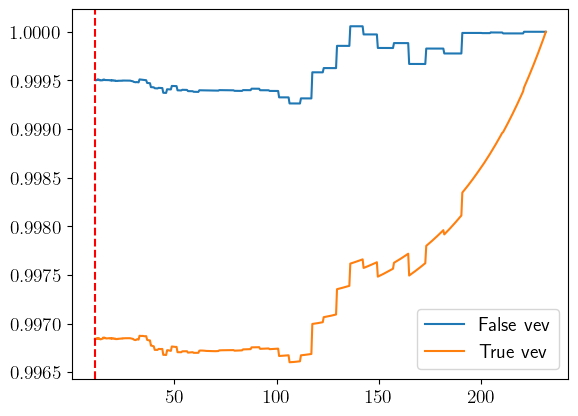

In [230]:
mask = Temps >= T_completion

vt_f = np.array([- dp.dVdT(false_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])
vtt_f = np.array([- dp.d2VdT2(false_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])

vt_t = np.array([- dp.dVdT(true_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])
vtt_t = np.array([- dp.d2VdT2(true_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])

#vtt = np.gradient(vt, Temps)

ln_a3_f = (-cumulative_trapezoid(((vtt_f/vt_f))[::-1], (Temps)[::-1], initial=0))[::-1]
ln_a3_t = (-cumulative_trapezoid(((vtt_t/vt_t))[::-1], (Temps)[::-1], initial=0))[::-1]

product_f = np.exp(ln_a3_f) * vt_f / vt_f[-1]
product_t = np.exp(ln_a3_t) * vt_t / vt_t[-1]

print("Range for false vev:", np.min(product_f[mask]), np.max(product_f[mask]))
print("Range for true vev:", np.min(product_t[mask]), np.max(product_t[mask]))

plt.plot(Temps[mask], product_f[mask], label = "False vev")
plt.plot(Temps[mask], product_t[mask], label = "True vev")
# for i in range(1,50):
#     plt.axvline(Temps[i], linestyle = "--")
plt.axvline(T_completion, linestyle = "--", color = 'red')
#plt.yscale('log')
#plt.xscale('log')
plt.legend()
plt.show()

In [231]:
num_stable = (product_f >= 0.99) & (product_f <= 1.01) & (product_t >= 0.99) & (product_t <= 1.01)

## $s(T)$

\begin{equation}
    s = P_f s_f + (1-P_f) s_t \tag{3}
\end{equation}

Text(0.5, 1.0, 'Vacua entropies')

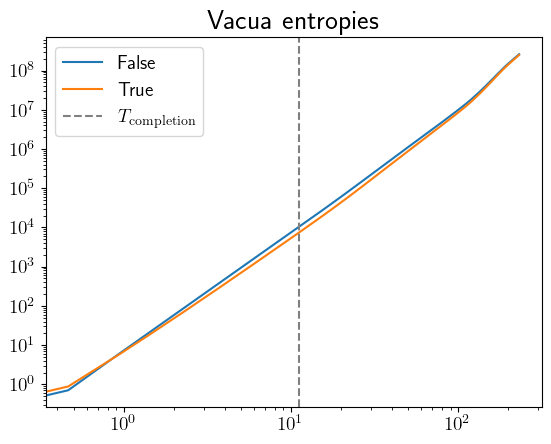

In [232]:
x = np.arange(-3, np.log10(2), 0.1)
temp = 10**x

s_t = np.array([- dp.dVdT(true_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])
s_f = np.array([- dp.dVdT(false_vev[Temps[i]], Temps[i], include_radiation=True, include_SM=True, units = units) for i in range(len(Temps))])

#s_t = np.array([- dp.dVdT(vev, temp[i], include_radiation=True, include_SM=True, units = units) for i in range(len(temp))])
#s_f = np.array([- dp.dVdT(0, temp[i], include_radiation=True, include_SM=True, units = units) for i in range(len(temp))])

plt.plot(Temps, s_f, label = "False")
plt.plot(Temps, s_t, label = "True")
plt.yscale('log')
plt.xscale('log')
plt.axvline(T_completion, color='grey', linestyle='--', label = '$T_{\\mathrm{completion}}$')
plt.legend()
plt.title("Vacua entropies")

In [233]:
P_f = np.exp(logP_f)
ratio_s = (P_f * s_f + (1 - P_f) * s_t ) / (s_f[-1])

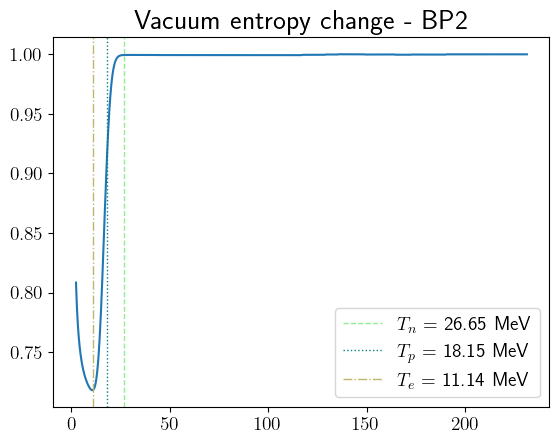

Text(0.5, 1.0, 'Vacuum entropy change - BP2')

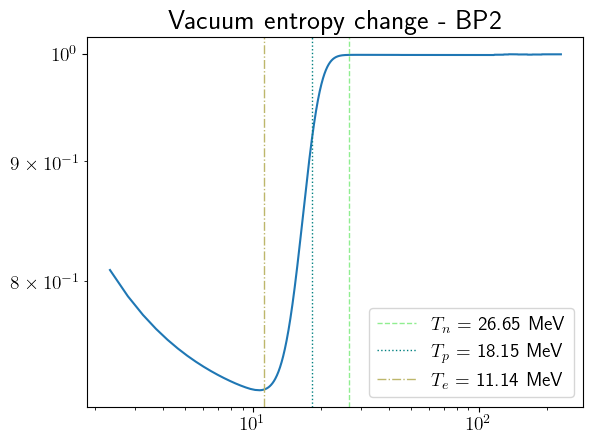

In [234]:
plt.plot(Temps[num_stable], (ratio_a3 * ratio_s)[num_stable])
#plt.plot(Temps, P_f)
plt.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
plt.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
plt.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2f} {units}')
plt.legend()
plt.title(f"Vacuum entropy change - {description}")
plt.show()


plt.plot(Temps[num_stable], (ratio_a3 * ratio_s)[num_stable])
#plt.plot(Temps, P_f)
plt.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
plt.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
plt.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2f} {units}')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.title(f"Vacuum entropy change - {description}")

## Total entropy $S$

\begin{equation}
    S_{rel} = \frac{S(T)}{S(T_c)} = \left(\frac{a(T)}{a(T_c)}\right)^3 \left(\frac{s(T)}{s(T_c)}\right) \tag{4}
\end{equation}

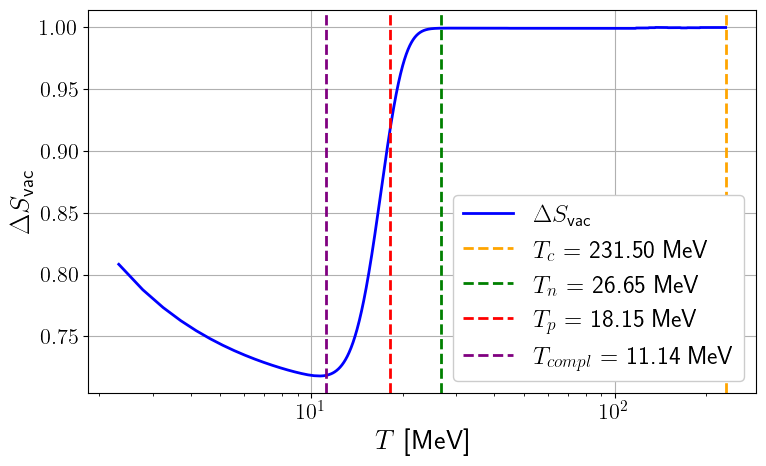

In [235]:
S_rel = ratio_a3 * ratio_s

plt.figure(figsize=(8, 5))
plt.plot(Temps[num_stable], S_rel[num_stable], linewidth=2, label=r'$\Delta S_\text{vac}$', color='b')
#plt.plot(Temps, P_f)
plt.axvline(x=T_max, color='orange', linestyle='--', linewidth=2, label = f"$T_{{c}}$ = {T_max:.2f} {units}")
plt.axvline(x=T_nuc, color='green', linestyle='--', linewidth=2, label = f"$T_{{n}}$ = {T_nuc:.2f} {units}")
plt.axvline(x=T_perc, color='red', linestyle='--', linewidth=2, label = f"$T_{{p}}$ = {T_perc:.2f} {units}")
plt.axvline(x=T_completion, color='purple', linestyle='--', linewidth=2, label = f"$T_{{compl}}$ = {T_completion:.2f} {units}")
plt.xlabel(f'$T$ [{units}]', fontsize=20)
plt.ylabel(r'$\Delta S_\text{vac}$', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xscale('log')
plt.legend(loc='best', framealpha=1, facecolor='white', fontsize=18)
plt.grid()
plt.tight_layout()
plt.show()

## Vacuum entropy

$s$ is computed using the dp.dVdT class model.

In [236]:
s_vac = - dp.dVdT(0, T_max, include_radiation=True, include_SM=True, units = units)
print(f'Vacuum entropy density at Tc is: {s_vac:.3e} MeV^3')

Vacuum entropy density at Tc is: 2.598e+08 MeV^3


## Radiation entropy
In the radiation-dominated era, the entropy density is given by  
\begin{equation}
   s = \frac{2\pi^2}{45} g_* T^3 \tag{5}
\end{equation}
where $ g_* $ is the effective number of relativistic degrees of freedom, and $ T $ is the temperature of the radiation.

In [237]:
#from ptarcade.models_utils import G, g_rho
from dof_interpolation import g_rho
s_r = 2. * np.pi**2/45. * (g_rho(T_max) + 4.) * T_max**3
print(f'Radiation entropy density at Tc is: {s_r:.3e} MeV^3')

Radiation entropy density at Tc is: 5.864e+08 MeV^3


## Entropy injected by supercooling

In [238]:
s_sup = (1. - S_rel[10]) * s_vac / s_r #put the index of the first point after T_compl
print(f'Fraction of entropy density injected by supercooling is: {s_sup:.3f}')

Fraction of entropy density injected by supercooling is: 0.112


## Dilution factor due to supercooling

In [239]:
d_sup = 1. + s_sup
print(f'Dilution factor due to supercooling: {d_sup:.5f}')

Dilution factor due to supercooling: 1.11159


## Dilution factor due to reheating

In https://arxiv.org/abs/2206.04691 they claim that
\begin{equation}
    d_{reh}=\left(\frac{T_{reh}}{T_{perc}}\right)^3 \tag{6}
\end{equation}

In [240]:
#BP1: T_reh = 53.84258297583765 MeV
#BP2: T_reh = 107.86173248327015 MeV
#BP3: T_reh = 0.31192040139339455 GeV
#BP4: T_reh = 0.12009972940357135 GeV
#MCMC_MAP: T_reh = 4.456097473516787 MeV
#MCMC_bayes: T_reh = 10.578342248326827 MeV
#MCMC_MLE: T_reh = 4.025017668663935 MeV
#Fast: T_reh = 39.858974755520876 MeV

In [241]:
d_reh = (4.456097473516787 / T_perc)**3 # insert T_reh
print(f'Dilution factor due to reheating: {d_reh:.3f}')

Dilution factor due to reheating: 0.015


# Total dilution factor

In [242]:
d_tot = d_sup * d_reh
print(f'Total dilution factor: {d_tot:.3f}')

Total dilution factor: 0.016


# Plot the evolution of the physical volume in the false vacuum
The figures below check if $\mathcal{V}_{phys}$ as defined in (4.64 in 2305.02357) is decreasing at a given temperature. Percolation and the production of GW are questionable if the volume is increasing at `T_perc` for a parameter point. This does not necessarily mean that such points do not produce GW (for instance before of after `T_perc`), however the computation of the resulting GW spectrum requires dedicated simulations, making the expressions used in `ELENA` not suitable for a reliable prediction.

**Do not trust the resulting GW spectrum if the variable `is_physical` is `False`**


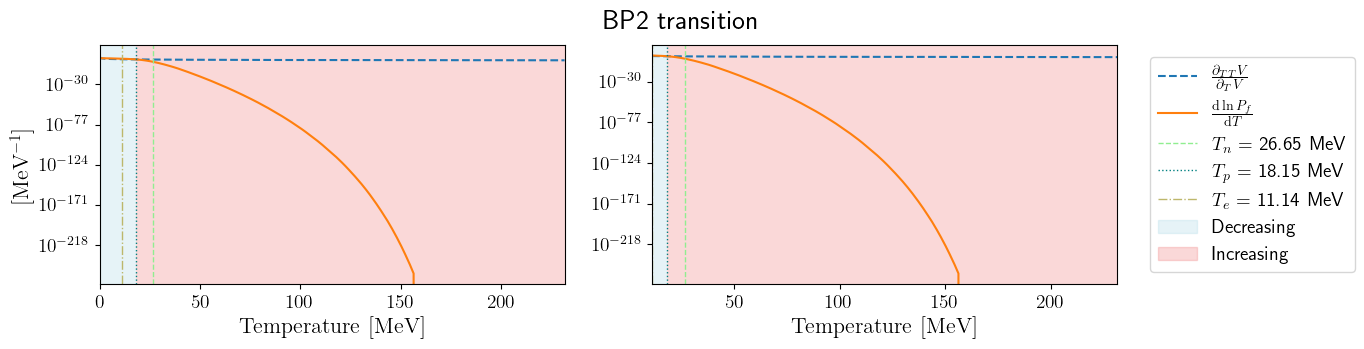

In [243]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# axes[0].plot(Temps, 3 / Temps, label = 'Bag model')
axes[0].plot(Temps, ratio_V, label = 'V_TT / V_T', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label = 'd/dT log(P_f)')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(f"$\mathrm{{[{units}^{{-1}}]}}$") #(f'$[{units}^{{-1}}]$')

# axes[1].plot(Temps[mask], 3 / Temps[mask], label = 'Bag model')
axes[1].plot(Temps[mask], ratio_V[mask], label = r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label = r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')

axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Create the legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='increasing')


for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2f} {units}')
    # ax.axhline(log_at_T_perc, color='lightgrey', linestyle='--', linewidth=1, label = f"d/dT log(P_f) = {log_at_T_perc:.2e}")
    # ax.axhline(ratio_V_at_T_perc, color='lightgreen', linestyle=':', linewidth=1, label = f"V_TT / V_T = {ratio_V_at_T_perc:.2e}")
    for i in range(len(Temps) - 1):
        if d_dT_logP_f[i] >= ratio_V[i]:
            ax.axvspan(Temps[i], Temps[i + 1], facecolor='lightblue', alpha=0.3)
        else:
            ax.axvspan(Temps[i], Temps[i + 1], facecolor='lightcoral', alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.89)
plt.tight_layout()
plt.savefig(figure_dir + f"volume_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

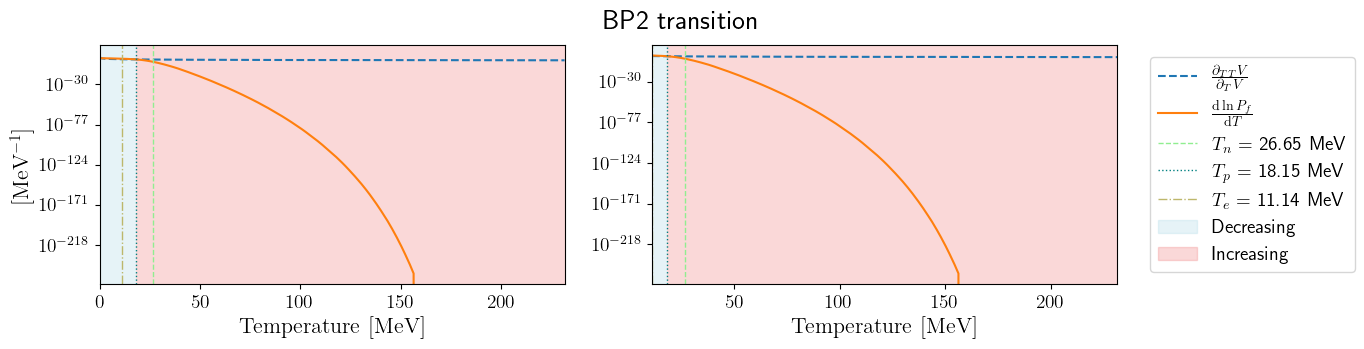

In [244]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot per il grafico intero
axes[0].plot(Temps, ratio_V, label = 'V_TT / V_T', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label = 'd/dT log(P_f)')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(f"$\\mathrm{{[{units}^{{-1}}]}}$")

# Plot per la vista ingrandita
axes[1].plot(Temps[mask], ratio_V[mask], label = r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label = r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Create the legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='increasing')

# Trova i punti di intersezione tra d_dT_logP_f e ratio_V
intersections = []
for i in range(len(Temps) - 1):
    # Controlla se c'è un'intersezione tra questi due punti
    if (d_dT_logP_f[i] - ratio_V[i]) * (d_dT_logP_f[i+1] - ratio_V[i+1]) <= 0:
        # Calcola il punto di intersezione esatto usando l'interpolazione lineare
        x1, x2 = Temps[i], Temps[i+1]
        y1, y2 = d_dT_logP_f[i] - ratio_V[i], d_dT_logP_f[i+1] - ratio_V[i+1]
        # Formula dell'intersezione con l'asse x (dove y = 0)
        intersection_x = x1 - y1 * (x2 - x1) / (y2 - y1)
        intersections.append(intersection_x)

# Aggiungi le intersezioni trovate ai punti originali per avere transizioni precise
all_points = np.sort(np.concatenate([Temps, intersections]))

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2f} {units}')
    
    # Colora lo sfondo usando i punti precisi delle intersezioni
    for i in range(len(all_points) - 1):
        # Trova il valore medio tra i due punti per determinare il colore
        mid_point = (all_points[i] + all_points[i+1]) / 2
        
        # Interpola il valore di d_dT_logP_f e ratio_V al punto medio
        d_dT_value = np.interp(mid_point, Temps, d_dT_logP_f)
        ratio_value = np.interp(mid_point, Temps, ratio_V)
        
        # Scegli il colore in base al confronto
        if d_dT_value >= ratio_value:
            ax.axvspan(all_points[i], all_points[i+1], facecolor='lightblue', alpha=0.3)
        else:
            ax.axvspan(all_points[i], all_points[i+1], facecolor='lightcoral', alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.89)
plt.tight_layout()
plt.savefig(figure_dir + f"volume_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Plot the evolution of the transition

## Full range of temperatures

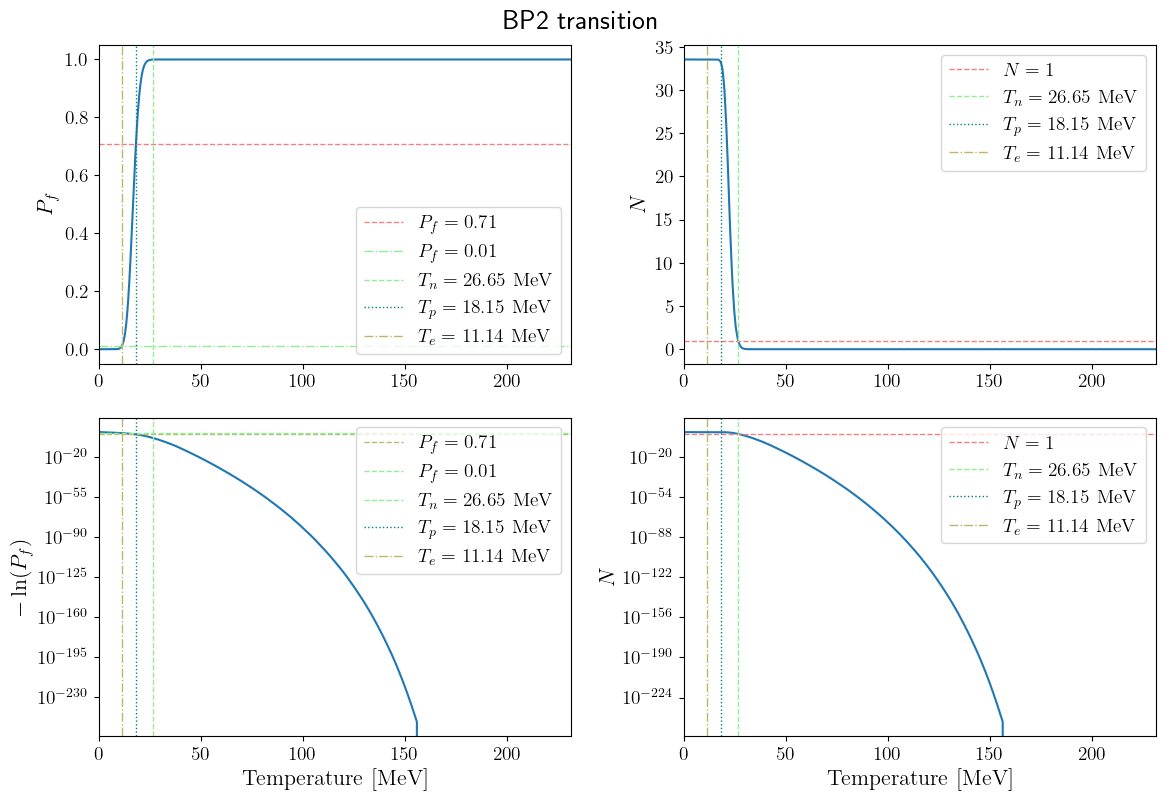

Average number of bubbles at T_min, N = 3.354e+01


In [245]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(Temps, np.exp(logP_f))
#axes[0,0].set_title('Fraction of universe in false vacuum')
#axes[0,0].set_xlabel(f'T [{units}]')  
axes[0,0].set_ylabel('$P_f$')
axes[0,0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=f'$P_f = 0.71$')
axes[0,0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=f'$P_f = 0.01$')
axes[0,0].legend()

axes[0,1].plot(Temps[mask_nH], nH[mask_nH])
axes[0,1].axhline(1, color='lightcoral', linestyle='--', linewidth=1, label=f'$N = 1$')
#axes[0,1].set_title('Bubbles per Hubble volume')
#axes[0,1].set_xlabel(f'Temperature [{units}]')
axes[0,1].set_ylabel('$N$')
axes[0,1].legend()

axes[1,0].plot(Temps, -logP_f)
axes[1,0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=f'$P_f = 0.71$')
axes[1,0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=f'$P_f = 0.01$')
#axes[1,0].set_title('(minus) Log of fraction of universe in false vacuum')
axes[1,0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel('$-\ln (P_f)$')
axes[1,0].set_yscale('log')
axes[1,0].legend()

axes[1,1].plot(Temps[mask_nH], nH[mask_nH])
axes[1,1].axhline(1, color='lightcoral', linestyle='--', linewidth=1, label=f'$N = 1$')
#axes[1,1].set_title('Bubbles per Hubble volume')
axes[1,1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel('$N$')
axes[1,1].set_yscale('log')
axes[1,1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
    ax.legend()

for ax in axes.flatten():
    ax.set_xlim(Temps[0], Temps[-1])

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)
plt.savefig(figure_dir + f"evolution_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Average number of bubbles at T_min, N = {nH[mask_nH][0]:.3e}")

## Range of temperatures zoomed over transition milestones

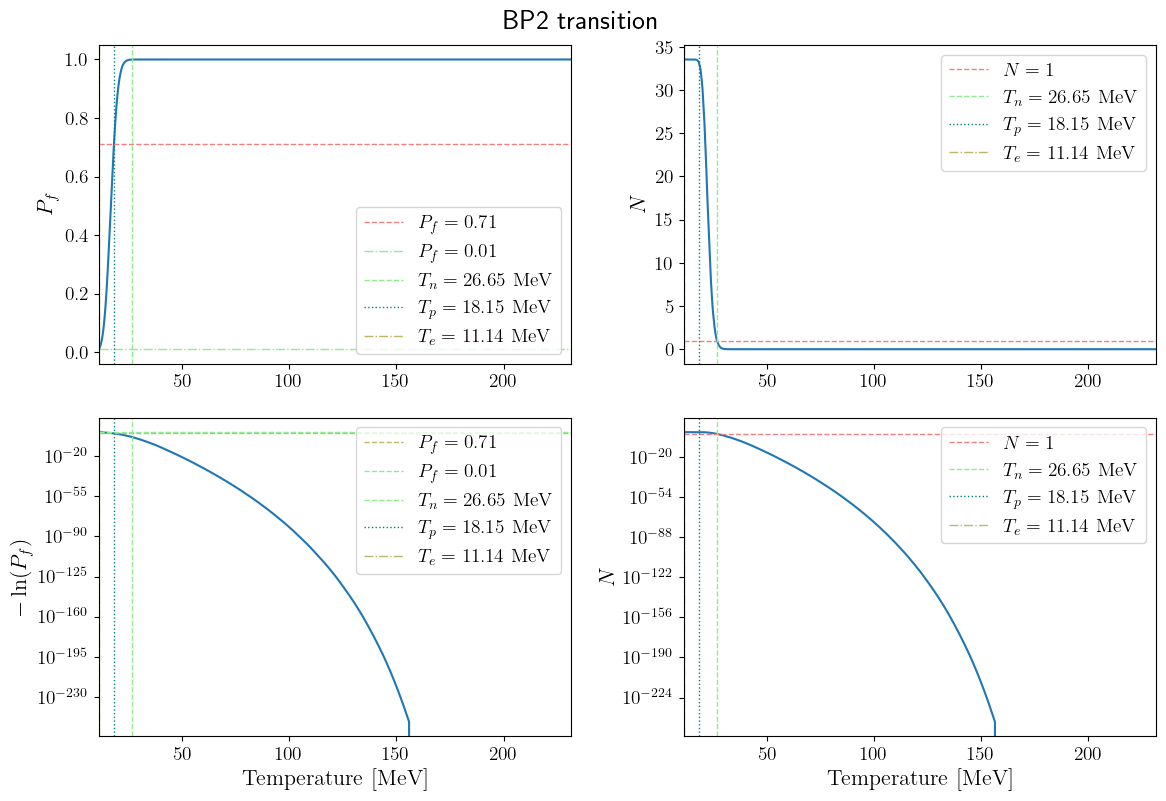

In [246]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(Temps[mask], np.exp(logP_f[mask]))
#axes[0,0].set_title('Fraction of universe in false vacuum')
#axes[0,0].set_xlabel(f'T [{units}]')  
axes[0,0].set_ylabel('$P_f$')
axes[0,0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=f'$P_f = 0.71$')
axes[0,0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=f'$P_f = 0.01$')
axes[0,0].legend()

axes[0,1].plot(Temps[mask], nH[mask])
axes[0,1].axhline(1, color='lightcoral', linestyle='--', linewidth=1, label=f'$N = 1$')
#axes[0,1].set_title('Bubbles per Hubble volume')
#axes[0,1].set_xlabel(f'Temperature [{units}]')
axes[0,1].set_ylabel('$N$')
axes[0,1].legend()

axes[1,0].plot(Temps[mask], -logP_f[mask])
axes[1,0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=f'$P_f = 0.71$')
axes[1,0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=f'$P_f = 0.01$')
#axes[1,0].set_title('(minus) Log of fraction of universe in false vacuum')
axes[1,0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel('$-\ln (P_f)$')
axes[1,0].set_yscale('log')
axes[1,0].legend()

axes[1,1].plot(Temps[mask], nH[mask])
axes[1,1].axhline(1, color='lightcoral', linestyle='--', linewidth=1, label=f'$N = 1$')
#axes[1,1].set_title('Bubbles per Hubble volume')
axes[1,1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel('$N$')
axes[1,1].set_yscale('log')
axes[1,1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
    ax.legend()

for ax in axes.flatten():
    ax.set_xlim(Temps[mask][0], Temps[mask][-1])

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)
plt.savefig(figure_dir + f"evolution_{description}_zoom.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Plot the tunneling quantities zoomed over milestone temperatures

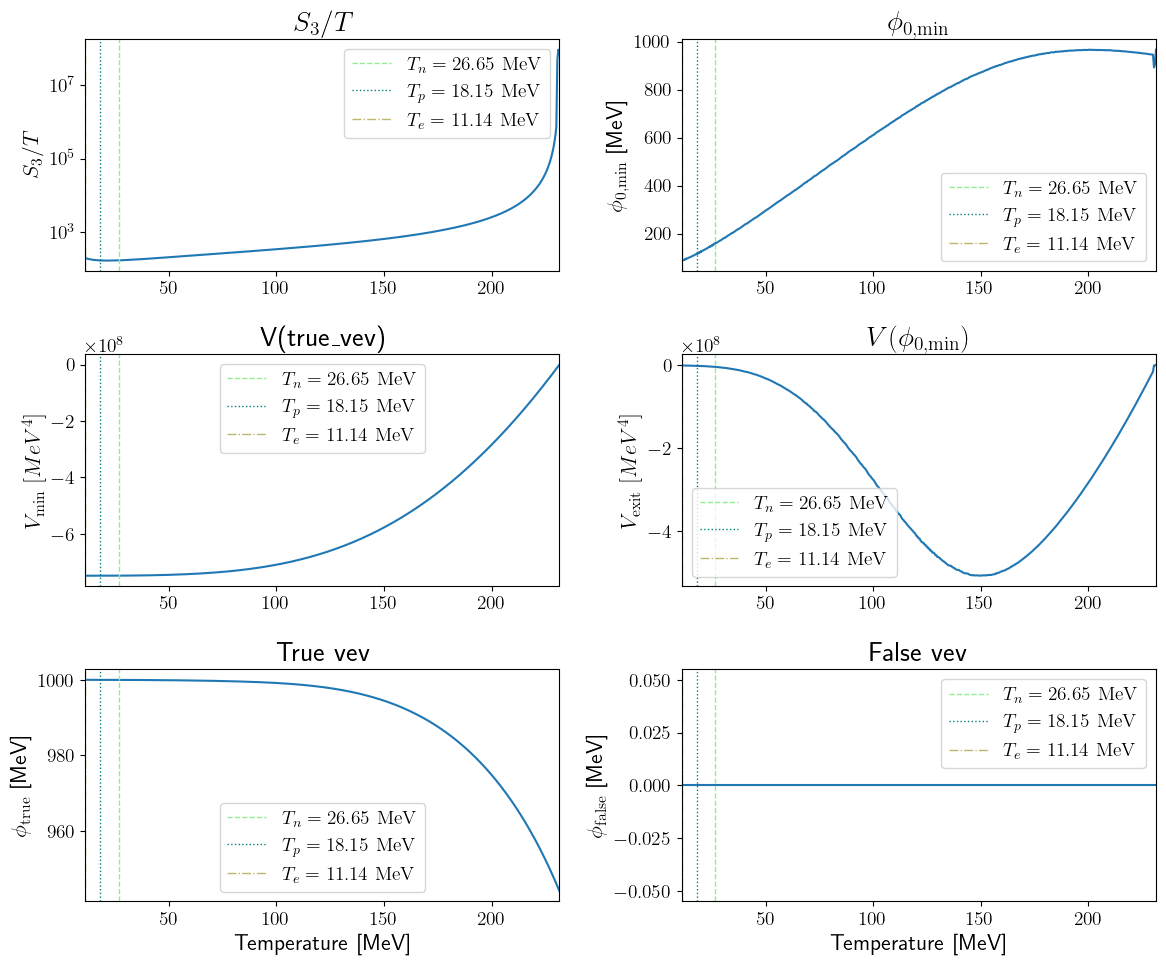

In [247]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(Temps[mask], [S3overT[T] for T in Temps[mask]])
axes[0, 0].set_title('$S_3/T$')
#axes[0, 0].set_xlabel(f"T [{units}]")
axes[0, 0].set_ylabel('$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(Temps[mask], [phi0_min[T] for T in Temps[mask]])
axes[0, 1].set_title('$\phi_{0,\mathrm{min}}$')
#axes[0, 1].set_xlabel(f"T [{units}]")
axes[0, 1].set_ylabel(f'$\\phi_{{0,\\mathrm{{min}}}}$ [{units}]')

axes[1, 0].plot(Temps[mask], [V_min_value[T] for T in Temps[mask]])
axes[1, 0].set_title('V(true_vev)')
#axes[1, 0].set_xlabel(f"T [{units}]")
axes[1, 0].set_ylabel(f'$V_{{\\mathrm{{min}}}}\ [{units}^4]$')

axes[1, 1].plot(Temps[mask], [V_exit[T] for T in Temps[mask]])
axes[1, 1].set_title('$V(\phi_{0,\mathrm{min}})$')
#axes[1, 1].set_xlabel(f"T [{units}]")
axes[1, 1].set_ylabel(f'$V_{{\\mathrm{{exit}}}}\ [{units}^4]$')

axes[2, 0].plot(Temps[mask], [true_vev[T] for T in Temps[mask]])
axes[2, 0].set_title('True vev')
axes[2, 0].set_xlabel(f"Temperature [{units}]")
axes[2, 0].set_ylabel(f'$\\phi_{{\\mathrm{{true}}}}$ [{units}]')

axes[2, 1].plot(Temps[mask], [false_vev[T] for T in Temps[mask]])
axes[2, 1].set_title('False vev')
axes[2, 1].set_xlabel(f"Temperature [{units}]")
axes[2, 1].set_ylabel(f'$\\phi_{{\\mathrm{{false}}}}$ [{units}]')

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
    ax.set_xlim(Temps[mask][0], Temps[mask][-1])
    ax.legend()

plt.tight_layout()
plt.show()

# Computation of thermal parameters determining the GW production

# $\alpha$ computation

The cell below computes the sound-speed in the plasma, that generally differs from the bag-model

/Users/michele/scratch/ELENA_release/src/GWparams.py:8: RuntimeWarning: divide by zero encountered in divide
  speed2 = m.dVdT(true_vev[T], T, include_radiation=True, include_SM = True, units = units) / (T * m.d2VdT2(true_vev[T], T, include_radiation=True, include_SM = True, units = units))


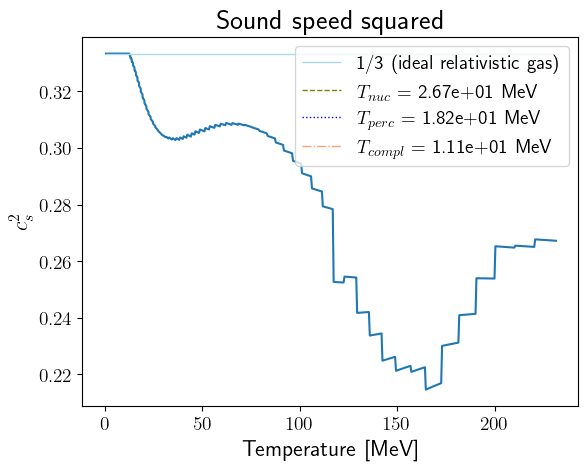

In [248]:
from GWparams import cs2

if T_perc is not None:
    action_over_T(T_perc)
    c_s2 = cs2(T_perc, dp, true_vev, units = units)

y = [cs2(T, dp, true_vev, units = units) for T in Temps]
plt.plot(Temps, y)
plt.hlines(1/3, Temps[0], Temps[-1], color='lightblue', linestyle='-', linewidth=1, label='1/3 (ideal relativistic gas)')
plt.vlines(T_nuc, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='olive', linestyle='--', linewidth=1, label=f'$T_{{nuc}}$ = {T_nuc:.2e} {units}')
plt.vlines(T_perc, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='blue', linestyle=':', linewidth=1, label=f'$T_{{perc}}$ = {T_perc:.2e} {units}')
plt.vlines(T_completion, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='lightsalmon', linestyle='-.', linewidth=1, label=f'$T_{{compl}}$ = {T_completion:.2e} {units}')
plt.title('Sound speed squared')
plt.xlabel(f'Temperature [{units}]')
plt.ylabel('$c_s^2$')
plt.legend()
plt.show()

The cell below contains the importation/definitions of:
- $\alpha$: following (5.29) in 2305.02357;
- $\alpha_\infty$: following 1004.4187;
- $\alpha_{eq}$: following 1903.09642.

In [249]:
from GWparams import alpha_th_bar # This is the definition of \alpha

def c_alpha_inf(T, units):
    v_true = true_vev[T]
    v_false = false_vev[T]
    Dm2_photon = 3 * g**2 * (v_true**2 - v_false**2)
    Dm2_scalar = 3 * lambda_ * (v_true**2 - v_false**2) 
    numerator = (Dm2_photon + Dm2_scalar) * T**2 / 24
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4
    return numerator/ rho_tot, numerator / rho_DS

def c_alpha_eq(T, units):
    v_true = true_vev[T]
    v_false = false_vev[T]
    numerator = (g**2 * 3 * (g * (v_true - v_false)) * T**3)
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4
    return numerator / rho_tot, numerator / rho_DS

The cell below computes the alphas at percolation. If `alpha < alpha_inf` the bubble nucleation is not in runaway regime, implying that the wall velocity $v_w$ does not converge asymptotically to 1. GW are still possible in this regime, however the computation of the transition temperatures and thermal parameters above is not reliable, since it assumes $v_w \rightarrow 1$. Thus the final GW spectrum should not be trust in this regime.

In [250]:
alpha, alpha_DS = alpha_th_bar(T_perc, dp, V_min_value, false_vev, true_vev, units = units)
alpha_inf, alpha_inf_DS = c_alpha_inf(T_perc, units)
alpha_eq, alpha_eq_DS = c_alpha_eq(T_perc, units)

gamma_eq = (alpha - alpha_inf) / alpha_eq
print(f"alpha = {alpha}")
print(f"alpha_inf = {alpha_inf}")
print(f"alpha_eq = {alpha_eq}")
print(f"gamma_eq = {gamma_eq}")

if alpha < alpha_inf:
    is_physical = False
    print("\n*** Warning, the bubble expansion is not in runaway regime! The results of the computation are not reliable ***")

v_min = 0.99

if gamma_eq < 1 / np.sqrt(1 - v_min**2):
    is_physical = False
    print(f"\n*** Warning, the NLO pressure could prevent the walls to reach relativistic velocities (gamma_eq = {gamma_eq:.2e}). The results of the computation are not reliable ***")

alpha = 1245.003276656769
alpha_inf = 37.890564886648875
alpha_eq = 12.249373230279772
gamma_eq = 98.54485524093627


/Users/michele/scratch/ELENA_release/src/GWparams.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  return (delta_rho - delta_p) / (3 * wf), (delta_rho - delta_p) / (3 * wf_DS)
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/2147266975.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return numerator/ rho_tot, numerator / rho_DS
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/2147266975.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return numerator/ rho_tot, numerator / rho_DS
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/2147266975.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / rho_tot, numerator / rho_DS
/var/folders/04/fp1djbdn4s5976r1jm7nkrsw0000gn/T/ipykernel_8125/2147266975.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / rho_tot, numerator / rho_DS


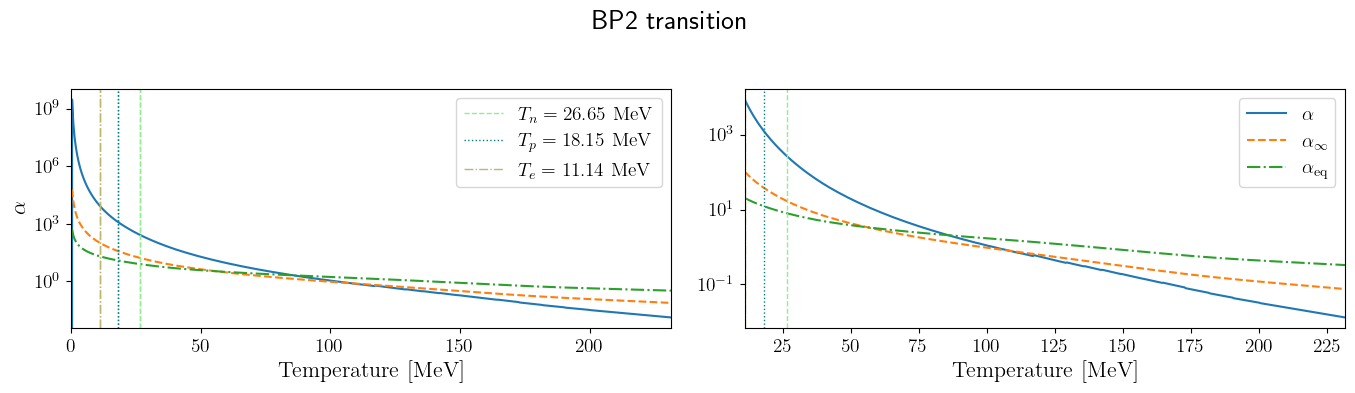

In [251]:
alpha_T = np.array([alpha_th_bar(T, dp, V_min_value, false_vev, true_vev, units)[0] for T in Temps])
alpha_inf_T = np.array([c_alpha_inf(t, units)[0] for t in Temps])
alpha_eq_T = np.array([c_alpha_eq(t, units)[0] for t in Temps])

amin, amax = min([np.nanmin(alpha_T), np.nanmin(alpha_inf_T), np.nanmin(alpha_eq_T)]), max([np.nanmax(alpha_T), np.nanmax(alpha_inf_T), np.nanmax(alpha_eq_T)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(Temps, alpha_T,linestyle='-') #label='$\\alpha$')
axes[0].plot(Temps, alpha_inf_T, linestyle='--') #label='$\\alpha_\infty$', )
axes[0].plot(Temps, alpha_eq_T,  linestyle='-.') #label='$\\alpha_\\mathrm{eq}$',)
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
axes[0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[0].set_ylabel('$\\alpha$')
axes[0].set_yscale('log')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].legend()

amin, amax = min([np.nanmin(alpha_T[mask]), np.nanmin(alpha_inf_T[mask]), np.nanmin(alpha_eq_T[mask])]), max([np.nanmax(alpha_T[mask]), np.nanmax(alpha_inf_T[mask]), np.nanmax(alpha_eq_T[mask])])
axes[1].plot(Temps[mask], alpha_T[mask], label='$\\alpha$', linestyle='-')
axes[1].plot(Temps[mask], alpha_inf_T[mask], label='$\\alpha_\infty$', linestyle='--')
axes[1].plot(Temps[mask], alpha_eq_T[mask], label='$\\alpha_\\mathrm{eq}$', linestyle='-.')
# axes[1].vlines(T_nuc, amin, amax, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
# axes[1].vlines(T_perc,amin, amax, color='lightblue', linestyle='-.', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
#axes[1].set_ylabel('$\\alpha$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

y_min, y_max = axes[1].get_ylim()
if 0.1 <= y_min and y_max <= 1:
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(-1,-1))
else:
    axes[1].set_yscale('log')
axes[1].legend()

# handles, labels = axes[1].get_legend_handles_labels()
# axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
    #custom_y_formatter(ax)

#fig.suptitle(f'Alpha comparison - {description}')
fig.suptitle(f'{description} transition', y=1.00)
plt.savefig(figure_dir + f"alpha_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Compute the mean bubble separation

In [252]:
from temperatures import R_sepH

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
RH_interp = interpolation_narrow(Temps, RH, T_perc)
H_star = interpolation_narrow(Temps, H, T_perc)
R_star = RH_interp / H_star

print(f"R* H* = {RH_interp:.2e}")

R* H* = 6.15e-01


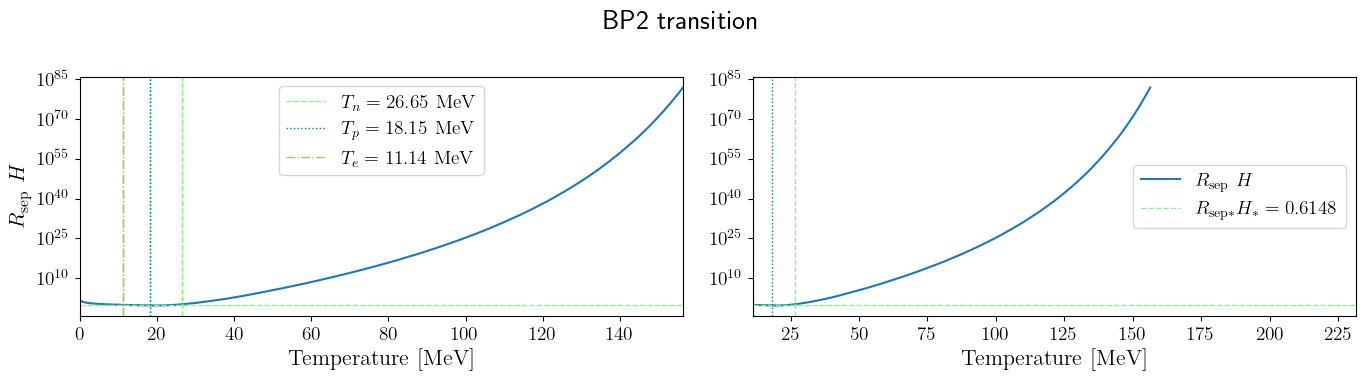

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, RH) #, label = '$R H$')
axes[0].set_ylabel('$R_\mathrm{sep}\ H$')
axes[0].set_yscale('log')
axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1) #, label=f'$R_* H_* = {RH_interp:.4f}$')
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
axes[0].set_xlim(Temps[0], Temps[np.max(np.where(RH < np.inf)[0])])
axes[0].legend()

axes[1].plot(Temps[mask], RH[mask], label = '$R_\mathrm{sep}\ H$')
#axes[1].set_ylabel('$R\ H$')
axes[1].set_yscale('log')
axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1, label=f'$R_\mathrm{{sep *}} H_* = {RH_interp:.4f}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])
axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2e} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2e} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2e} {units}')
    ax.set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")

# handles, labels = axes[1].get_legend_handles_labels()
# axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

#fig.suptitle(f'Mean bubble separation - {description}')
fig.suptitle(f'{description} transition', y=0.97)
plt.savefig(figure_dir + f"RH_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [254]:
T_perc

np.float64(18.151815606397196)

## Compute the efficiency factors

The cell below computes the efficiency factors of the transition following the expressions in 1903.09642.

/Users/michele/scratch/ELENA_release/src/temperatures.py:630: RuntimeWarning: invalid value encountered in scalar multiply
  E0V = S3_T[T] * T / 2 # this is the potential energy contribution only
/Users/michele/scratch/ELENA_release/src/temperatures.py:632: RuntimeWarning: invalid value encountered in power
  r0 = ((3 * E0V / (4*np.pi*DV))**(1/3.0))


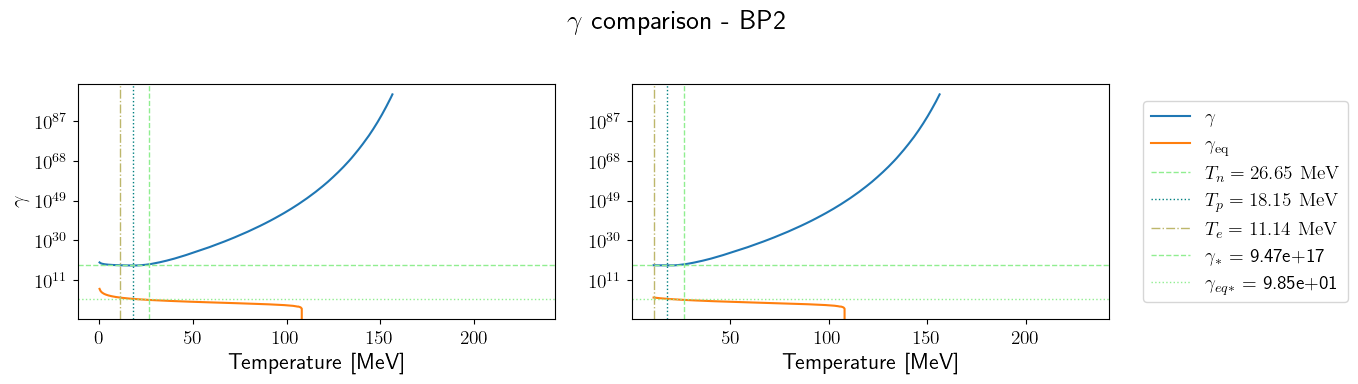

In [255]:
from temperatures import R0

r0 = np.array([R0(T, S3overT, V_exit) for T in Temps])

gamma_eq_T = (alpha_T - alpha_inf_T) / alpha_eq_T
gamma = 2 * R / (3 * r0)

gamma_star = 2 * R_star / (3 * R0(T_perc, S3overT, V_exit))
gamma_eq_star = interpolation_narrow(Temps, gamma_eq_T, T_perc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, gamma, label='$\gamma$')
axes[0].plot(Temps, gamma_eq_T, label='$\gamma_\mathrm{eq}$')
axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel('$\gamma$')

axes[1].plot(Temps[mask], gamma[mask], label='$\gamma$')
axes[1].plot(Temps[mask], gamma_eq_T[mask], label='$\gamma_\mathrm{eq}$')
axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')
#axes[1].set_ylabel('$\gamma$')
axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
    ax.axhline(gamma_star, color='lightgreen', linestyle='--', linewidth=1, label=f'$\gamma_*$ = {gamma_star:.2e}')
    ax.axhline(gamma_eq_star, color='lightgreen', linestyle=':', linewidth=1, label=f'$\gamma_{{eq*}}$ = {gamma_eq_star:.2e}')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'$\gamma$ comparison - {description}')
plt.tight_layout()
plt.show()

# Check the nucleation process

The cells below fit the nucleation rate around the nucleation time to the relation 
$$
\Gamma(t - t_n) = H_n^4 \exp\left[\beta (t - t_n) - \frac{1}{2} \gamma^2 (t - t_n)^2 \right],
$$
where $H_n = H(t = t_n)$ is the Hubble rate at the nucleation time $t_n$ (defined as the time when $T = T_{nuc}$). The fit is performed until percolation.

If $\gamma / \beta \ll 1$ the nucleation process is exponential, otherwise second order corrections are important.

In [256]:
from GWparams import beta

logP_f, Temps, ratio_V, Gamma, H = compute_logP_f(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_nuc, T_perc, verbose = True)

# delta = (T_nuc - T_perc) / 2
# beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_perc + delta, T_perc - delta, verbose = True)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 17.650059809028104
gamma = 9.650518257904087


Below we plot the results:

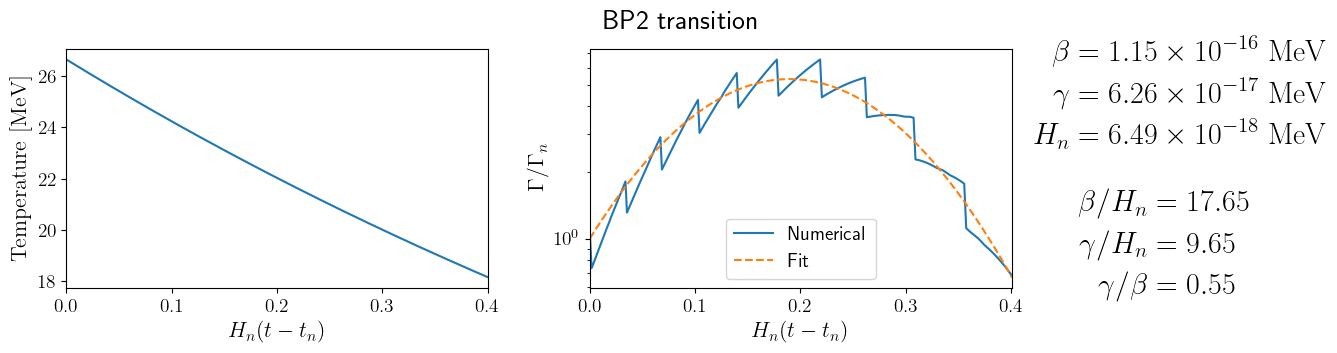

Percolation at 4.01e-01


In [257]:
Gamma_n = Gamma_t[0]
H_n = H_t[0]

def scientific_notation(number):
    exponent = int(np.floor(np.log10(abs(number))))
    coefficient = number / 10**exponent
    return f"{coefficient:.2f} \\times 10^{{{exponent}}}"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(times, Temps_t)
axes[0].set_xlabel("$H_n (t-t_n)$")
axes[0].set_ylabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[0].set_xlim((times)[0], (times)[-1])


box_text = r"$\begin{aligned}" + \
           rf"\beta &= {scientific_notation(beta_Hn*H_n)}\ \mathrm{{{units}}}" + r"\\" + \
           rf"\gamma &= {scientific_notation(gamma_Hn*H_n)}\ \mathrm{{{units}}}" + r"\\" + \
           rf"H_n &= {scientific_notation(H_n)}\ \mathrm{{{units}}}" + \
           r"\end{aligned}$" + \
           r"\\[1em]" + \
           r"$\begin{aligned}" + \
           rf"\phantom{{AAA}} \beta / H_n &= {beta_Hn:.2f}" + r"\\" + \
           rf" \gamma / H_n &= {gamma_Hn:.2f}" + r"\\" + \
           rf" \gamma / \beta &= {gamma_Hn/beta_Hn:.2f}" + \
           r"\end{aligned}$"

axes[1].plot(times, Gamma_t / Gamma_t[0], label ="Numerical")
tfit = np.linspace(times[0], times[-1], 100, endpoint=True)
axes[1].plot(tfit, np.exp(beta_Hn*tfit - (gamma_Hn*tfit)**2 / 2), label = "Fit", linestyle='--')
axes[1].set_xlabel("$H_n (t-t_n)$")
axes[1].set_ylabel("$\Gamma / \Gamma_n$")
#axes[1].set_title(f"Decay rate - {description}")
axes[1].set_yscale('log')
axes[1].set_xlim(times[0], times[-1])
axes[1].text(1.4, 0.5, box_text,       # coordinates (0-1 for normalized)
        fontsize='large',
        transform=axes[1].transAxes,       # use normalized coordinates
        horizontalalignment='center',      # center text horizontally
        verticalalignment='center')        # center text vertically 
axes[1].legend()

plt.suptitle(f'{description} transition', y=0.9)
plt.tight_layout()
plt.savefig(figure_dir + f"nucleation_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Percolation at {times[-1]:.2e}")

# Compute gravitational waves spectrum

We import the periodograms from the NANOGrav 15-years dataset

In [258]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the original figure
with open('../data/processed/plots/NG15.pkl', 'rb') as f:
    fig, ax = pickle.load(f)

# Create a new figure with linear scales
fig_linear, ax_linear = plt.subplots(figsize=fig.get_size_inches())

# Extract and convert all collections from the logarithmic plot
for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # Extract path data
        path = collection.get_paths()[0]
        vertices = path.vertices
        
        if len(vertices) > 0:
            x_log = vertices[:, 0]  # Log10 values
            y_log = vertices[:, 1]  # Log10 values
            
            # Convert to linear scale
            x_linear = 10**x_log
            y_linear = 10**y_log
            
            # Plot with original styling
            ax_linear.fill(x_linear, y_linear, 
                          facecolor=collection.get_facecolor()[0],
                          edgecolor=collection.get_edgecolor()[0],
                          alpha=collection.get_alpha())

# Set linear scales
ax_linear.set_xscale('linear')
ax_linear.set_yscale('linear')

# Copy labels from original
ax_linear.set_xlabel(ax.get_xlabel())
ax_linear.set_ylabel(ax.get_ylabel())
ax_linear.set_title(ax.get_title())

plt.close(fig)
plt.close(fig_linear)

Plot the gravitational waves spectrum over large range of frequency (default $[10^{-10}, 10^{10}]$ hz), following the expressions in 1903.09642.

Is physical? True
lambda = 0.006
g = 0.74999
vev = 1000 MeV
m_phi = 109.54451150103323 MeV
m_Z = 749.99 MeV
T_crit = 231.5 MeV
T_nuc = 26.651464456874336 MeV
T_perc = 18.151815606397196 MeV
T_completion = 11.136734757996757 MeV
T_min = 0 MeV
T_reh = 107.84496336667304 MeV
Minimal value of P_f = 4.624136249500734e-15
alpha = 1245.003276656769, alpha_inf = 37.890564886648875, alpha_eq = 12.249373230279772
gamma_* = 9.467131088777087e+17, gamma_eq = 98.54485524093627
Is runaway? True
RH = 0.6147797369013578


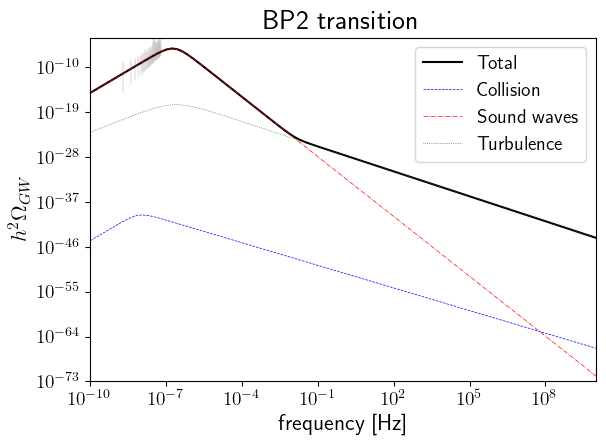

In [259]:
import pickle 
from GWparams import GW_SuperCooled
import contextlib

def print_params():
    print(f"Is physical? {is_physical}")
    print(f"lambda = {lambda_}")
    print(f"g = {g}")
    print(f"vev = {vev} {units}")
    print(f"m_phi = {np.sqrt(2*lambda_)*vev} {units}")
    print(f"m_Z = {g*vev} {units}")
    print(f"T_crit = {T_max} {units}")
    print(f"T_nuc = {T_nuc} {units}")
    print(f"T_perc = {T_perc} {units}")
    print(f"T_completion = {T_completion} {units}")
    print(f"T_min = {T_min} {units}")
    print(f"T_reh = {(1+alpha)**(1/4) * T_perc} {units}")
    print(f"Minimal value of P_f = {np.nanmin(np.exp(logP_f))}")
    print(f"alpha = {alpha}, alpha_inf = {alpha_inf}, alpha_eq = {alpha_eq}")
    print(f"gamma_* = {gamma_star}, gamma_eq = {gamma_eq}")
    print(f"Is runaway? {alpha > alpha_inf}")
    print(f"RH = {R_star * H_star}")
    #print(f"beta/H_n = {beta_H0}, gamma/H_n = {gamma_H0}, gamma/beta = {gamma_H0/beta_H0}")

# Save the relevant reults to a file
with open(f'../data/processed/plots/{description}.txt', 'w') as f:
    with contextlib.redirect_stdout(f):
        print_params()

log_freq_min = -10
log_freq_max = 10

if T_perc is not None:
    inst = GW_SuperCooled(T_perc, alpha, alpha_inf, alpha_eq, R_star, gamma_star, H_star, c_s = np.sqrt(c_s2), units = units)
    print_params()

    x = np.linspace(log_freq_min, log_freq_max, 100)
    x = 10**x
    ax_linear.plot(x, inst.Omegah2(x), label = "Total", color='black')
    ax_linear.plot(x, inst.Omegah2coll(x), label = "Collision", linewidth=0.5, color='blue', linestyle='--')
    ax_linear.plot(x, inst.Omegah2sw(x), label = "Sound waves", linewidth=0.5, color='red', linestyle='-.')
    ax_linear.plot(x, inst.Omegah2turb(x), label = "Turbulence", linewidth=0.5, color='green', linestyle=':')
    ax_linear.set_xlim(x[0], x[-1])
    ax_linear.set_ylim(1e-73, 1e-4)
    ax_linear.set_xscale('log')
    ax_linear.set_yscale('log')
    ax_linear.set_xlabel('frequency [Hz]')
    ax_linear.set_ylabel('$h^2 \Omega_{GW}$')
    #plt.title(f'GW spectrum - {description}')
    ax_linear.legend()
    ax_linear.set_title(f'{description} transition', y=1)
    fig_linear.savefig(figure_dir + f"GW_{description}.pdf", dpi=300, bbox_inches='tight')
    fig_linear.tight_layout()

# Save the for spectrum future plotting
if is_physical:
    with open(f'../data/processed/plots/GW_{description}.pkl', 'wb') as f:
        pickle.dump(inst, f)

fig_linear

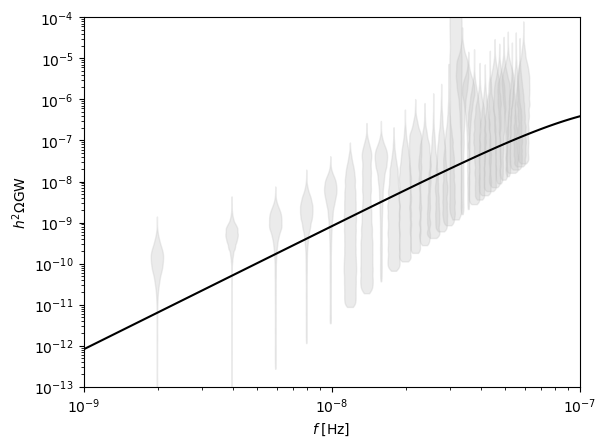

In [260]:
from matplotlib import ticker
import contextlib

def myticks(x,pos):
    exponent = int(x)
    coeff = x/10**exponent
    return r"$10^{{ {:2d} }}$".format(exponent)

with open('../data/processed/plots/NG15.pkl', 'rb') as f:
    fig, ax = pickle.load(f)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(myticks))
major = np.linspace(-100, 100, 201)
ax.xaxis.set_major_locator(ticker.FixedLocator(major))
minors = np.array([ -50+(np.floor(i/10)+np.log10(1+10*(i/10-np.floor(i/10)))) for i in np.arange(1,1000,1)])
ax.xaxis.set_minor_locator(ticker.FixedLocator(minors))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(myticks))
major = np.linspace(-100, 100, 201)
ax.yaxis.set_major_locator(ticker.FixedLocator(major))
minors = np.array([ -50+(np.floor(i/10)+np.log10(1+10*(i/10-np.floor(i/10)))) for i in np.arange(1,1000,1)])
ax.yaxis.set_minor_locator(ticker.FixedLocator(minors))


if T_perc is not None:
    x = np.linspace(-7, -9, 100)
    x = 10**x
    ax.plot(np.log10(x), np.log10(inst.Omegah2(x)), label = "Total", color='black')
    plt.margins(0)
    ax.set_ylim(-13, -4)
#     ax.plot(np.log10(x), np.log10(inst.Omegah2coll(x)), label = "Collision", linewidth=0.5, color='blue')
#     plt.plot(x, inst.Omegah2sw(x), label = "Sound waves", linewidth=0.5, color='red')
#     plt.plot(x, inst.Omegah2turb(x), label = "Turbulence", linewidth=0.5, color='green')
#     if obs is not None:
#         plt.plot(x, obs.h2Omega_0_sum(x), label = "TransitionListener total", linestyle='--', color='black')
#         plt.plot(x, obs.h2Omega_0('scalar field', x), label = "TransitionListener collision", linestyle='--', linewidth=0.5, color='blue')
#         plt.plot(x, obs.h2Omega_0('sound waves', x), label = "TransitionListener sound waves", linestyle='--', linewidth=0.5, color='red')
#         plt.plot(x, obs.h2Omega_0('turbulence', x), label = "TransitionListener turbulence", linestyle='--', linewidth=0.5, color='green')
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.legend()
#     plt.plot()

In [261]:
inst.Omegah2([[1.97682646e-09],
 [3.95365292e-09],
 [5.93047937e-09],
 [7.90730583e-09],
 [9.88413229e-09],
 [1.18609587e-08],
 [1.38377852e-08],
 [1.58146117e-08],
 [1.77914381e-08],
 [1.97682646e-08],
 [2.17450910e-08],
 [2.37219175e-08],
 [2.56987439e-08],
 [2.76755704e-08]])

array([[6.30841546e-12],
       [5.04178088e-11],
       [1.69882051e-10],
       [4.01762982e-10],
       [7.82389808e-10],
       [1.34712493e-09],
       [2.13013828e-09],
       [3.16419188e-09],
       [4.48043662e-09],
       [6.10822319e-09],
       [8.07492741e-09],
       [1.04057934e-08],
       [1.31237931e-08],
       [1.62495057e-08]])

In [ ]:
# Reload temperatures module and test compute_logP_f5
import importlib
import temperatures
importlib.reload(temperatures)
from temperatures import compute_logP_f5

# Test the new implementation
v_w = 1.0

logP_f5, Temps5, R5, Gamma5, H5 = compute_logP_f5(dp, V_min_value, S3overT, true_vev, false_vev, v_w, units=units)

print(f"Temps5 range: {Temps5.min():.2f} - {Temps5.max():.2f} {units}")
print(f"logP_f5 range: {logP_f5.min():.6e} to {logP_f5.max():.6e}")
print(f"logP_f5[0] at T_max: {logP_f5[-1]:.6e}")
print(f"logP_f5[-1] at T_min: {logP_f5[0]:.6e}")